# Attestation timings - late arrivals

#### Maria Silva, July 2025


## 1. Imports

In [5]:
import os
import shap
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report,
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
model_out_dir = os.path.join(repo_dir, "data", "model_outputs")

In [4]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Process data

In [4]:
file_dir = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
val_df = pd.read_parquet(file_dir)
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2031272 entries, 0 to 2031271
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   index   int64 
 1   entity  object
dtypes: int64(1), object(1)
memory usage: 31.0+ MB


In [5]:
file_dir = os.path.join(
    repo_dir, "data", "sample_12187616_12202016", "slot_info.parquet"
)
slot_df = pd.read_parquet(file_dir)
slot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   slot                          2820 non-null   int64         
 1   request_datetime              2820 non-null   datetime64[ns]
 2   publish_datetime              2820 non-null   datetime64[ns]
 3   header_from                   2820 non-null   object        
 4   slot_start_datetime           2820 non-null   datetime64[ns]
 5   request_time_ms               2820 non-null   float64       
 6   publish_time_ms               2820 non-null   float64       
 7   p95_block_arrival_ms          2820 non-null   int64         
 8   p66_block_arrival_ms          2820 non-null   int64         
 9   avg_block_arrival_ms          2820 non-null   float64       
 10  block_total_bytes_compressed  2820 non-null   int64         
 11  block_proposer_index          

In [6]:
file_dir = os.path.join(
    repo_dir, "data", "sample_12187616_12202016", "sample_atts.parquet"
)
atts_df = pd.read_parquet(file_dir)
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2852445 entries, 0 to 2852444
Data columns (total 4 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   slot                  int64 
 1   atts_validator        int64 
 2   atts_subnet           object
 3   atts_arrival_time_ms  int64 
dtypes: int64(3), object(1)
memory usage: 87.0+ MB


In [7]:
df = (
    atts_df
    .merge(slot_df, on="slot", how="left")
    .merge(val_df, right_on="index", left_on="atts_validator", how="left")
    .drop(columns=["index"])
    .fillna({"entity": "Unknown"})
)
df["net_atts_arrival_time_ms"] = df["atts_arrival_time_ms"]-df["publish_time_ms"]
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2857775 entries, 0 to 2857774
Data columns (total 19 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   slot                          2857775 non-null  int64         
 1   atts_validator                2857775 non-null  int64         
 2   atts_subnet                   2857775 non-null  object        
 3   atts_arrival_time_ms          2857775 non-null  int64         
 4   request_datetime              2857775 non-null  datetime64[ns]
 5   publish_datetime              2857775 non-null  datetime64[ns]
 6   header_from                   2857775 non-null  object        
 7   slot_start_datetime           2857775 non-null  datetime64[ns]
 8   request_time_ms               2857775 non-null  float64       
 9   publish_time_ms               2857775 non-null  float64       
 10  p95_block_arrival_ms          2857775 non-null  int64         
 11

## 3. EDA

### Sample size / counts

In [8]:
print(df["slot"].nunique())
df["slot"].agg(["min", "max"])

2690


min    12187617
max    12201980
Name: slot, dtype: int64

In [9]:
df.groupby("header_from").size().sort_values(ascending=False)/len(df)

header_from
ultrasound    0.503380
self_build    0.349257
titan         0.147363
dtype: float64

In [10]:
df.groupby("entity").size().sort_values(ascending=False)/len(df)

entity
solo_stakers            8.492691e-02
binance                 8.451155e-02
coinbase                7.063887e-02
ether.fi                6.864571e-02
kiln                    4.334421e-02
                            ...     
csm_operator216_lido    3.499226e-07
csm_operator44_lido     3.499226e-07
whale_0xa169            3.499226e-07
csm_operator316_lido    3.499226e-07
csm_operator313_lido    3.499226e-07
Length: 737, dtype: float64

### Arrival times distribution

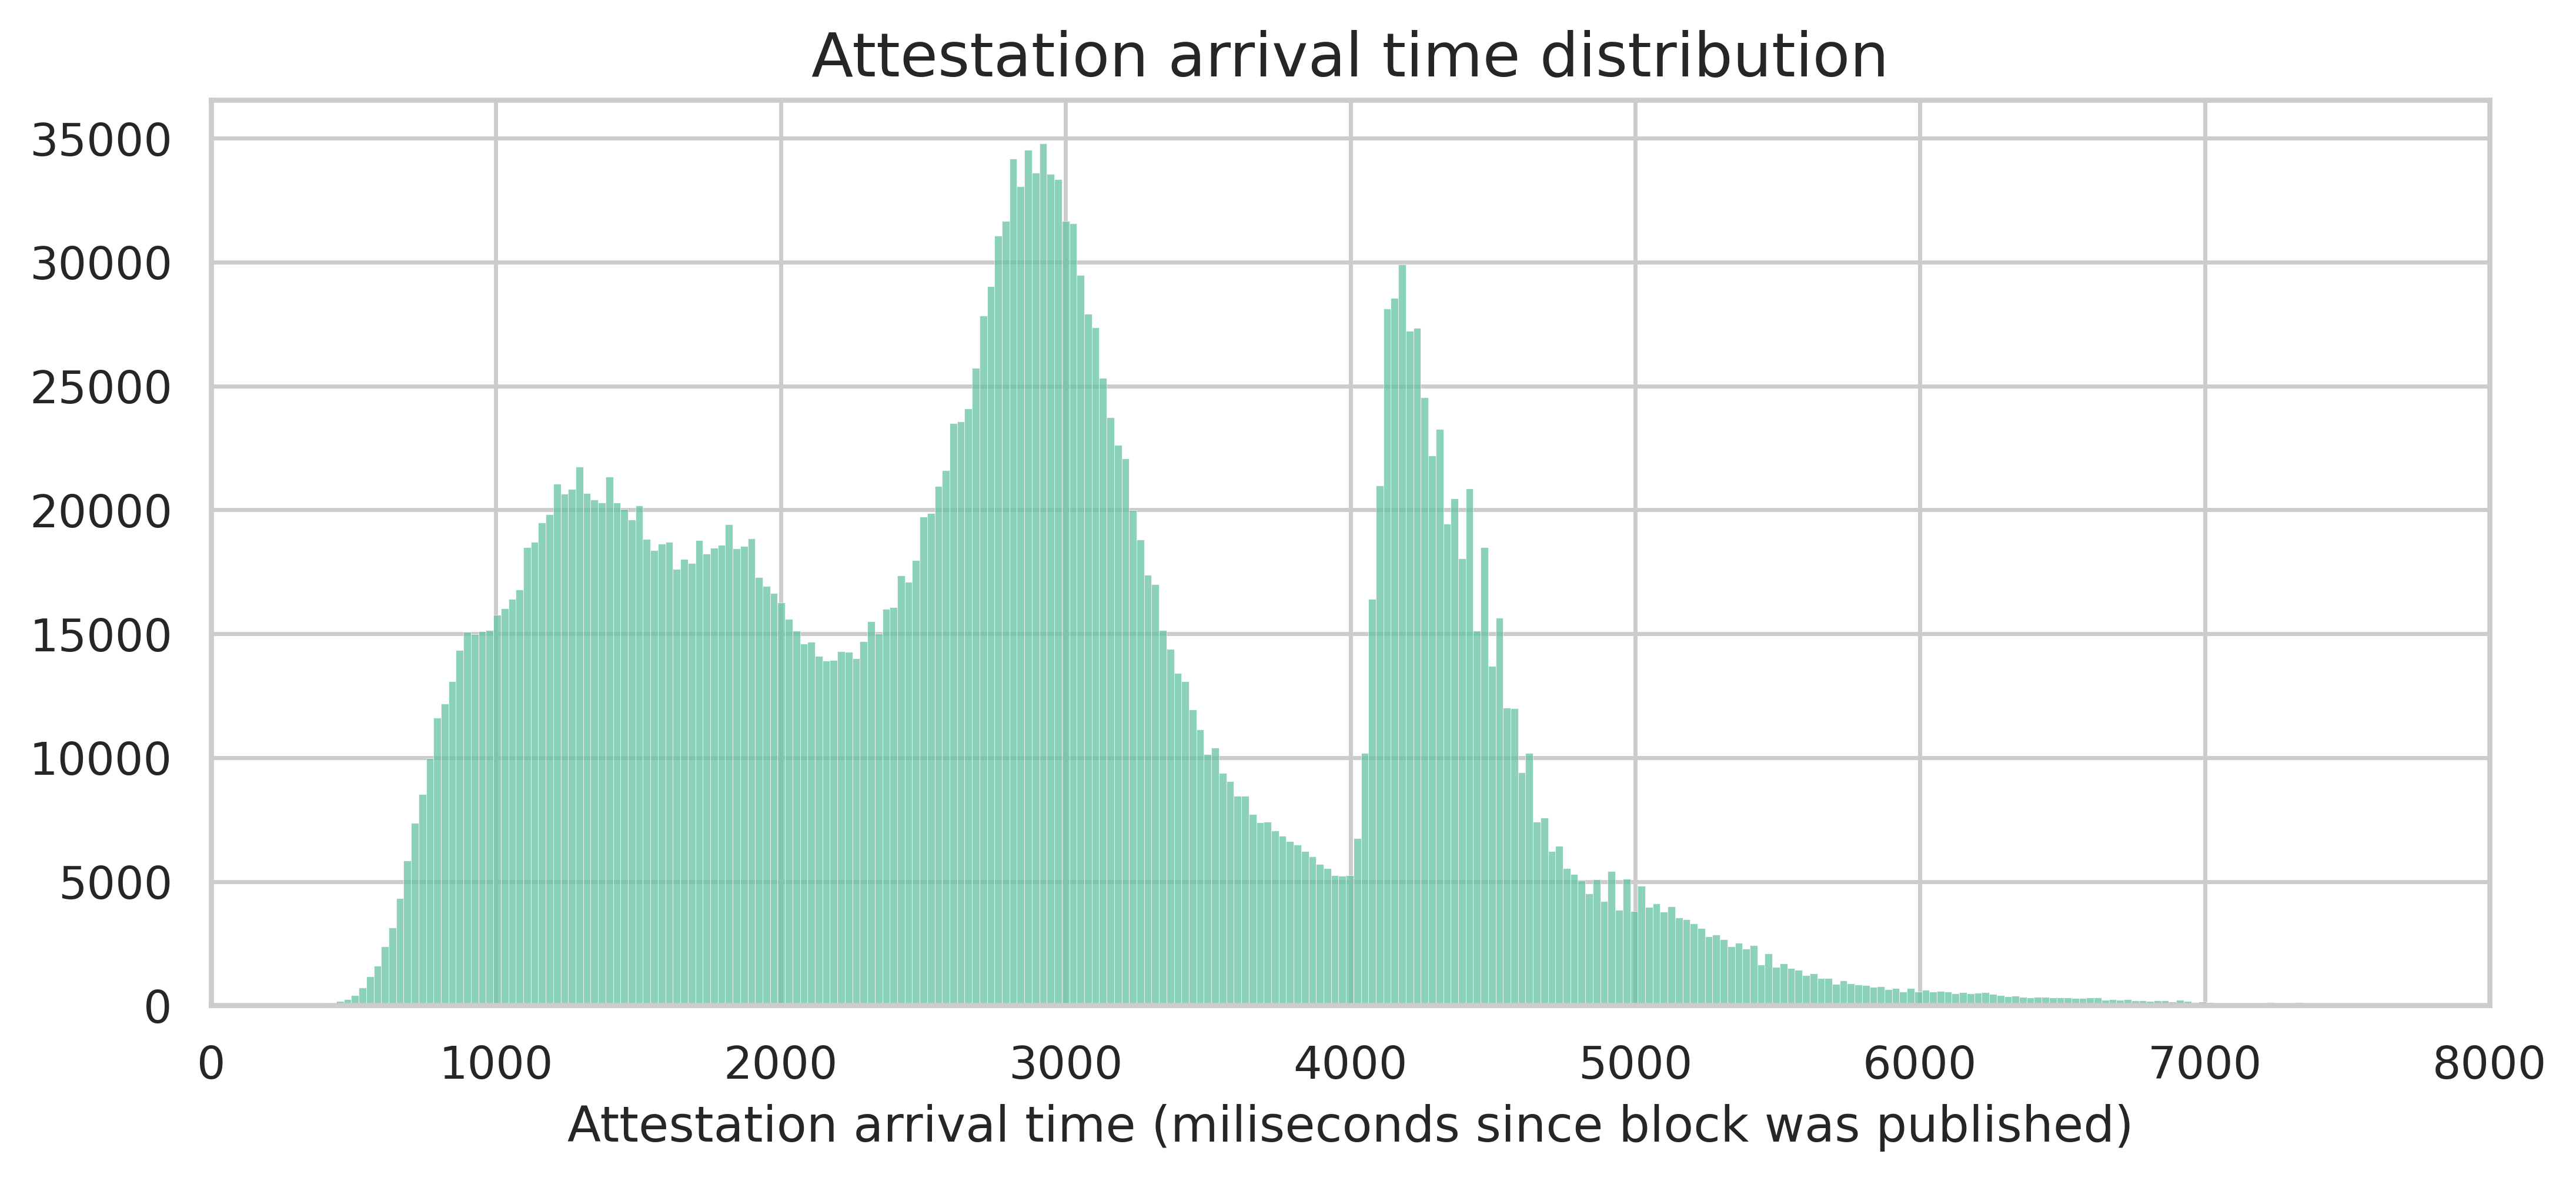

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df,
    x="net_atts_arrival_time_ms"
)
plt.xlim(0,8000)
plt.title("Attestation arrival time distribution")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since block was published)")
plt.show()

In [12]:
sum(df["net_atts_arrival_time_ms"]>4500), sum(df["net_atts_arrival_time_ms"]>4500)/len(df)

(231311, 0.08094094181662308)

### Arrival times by block source

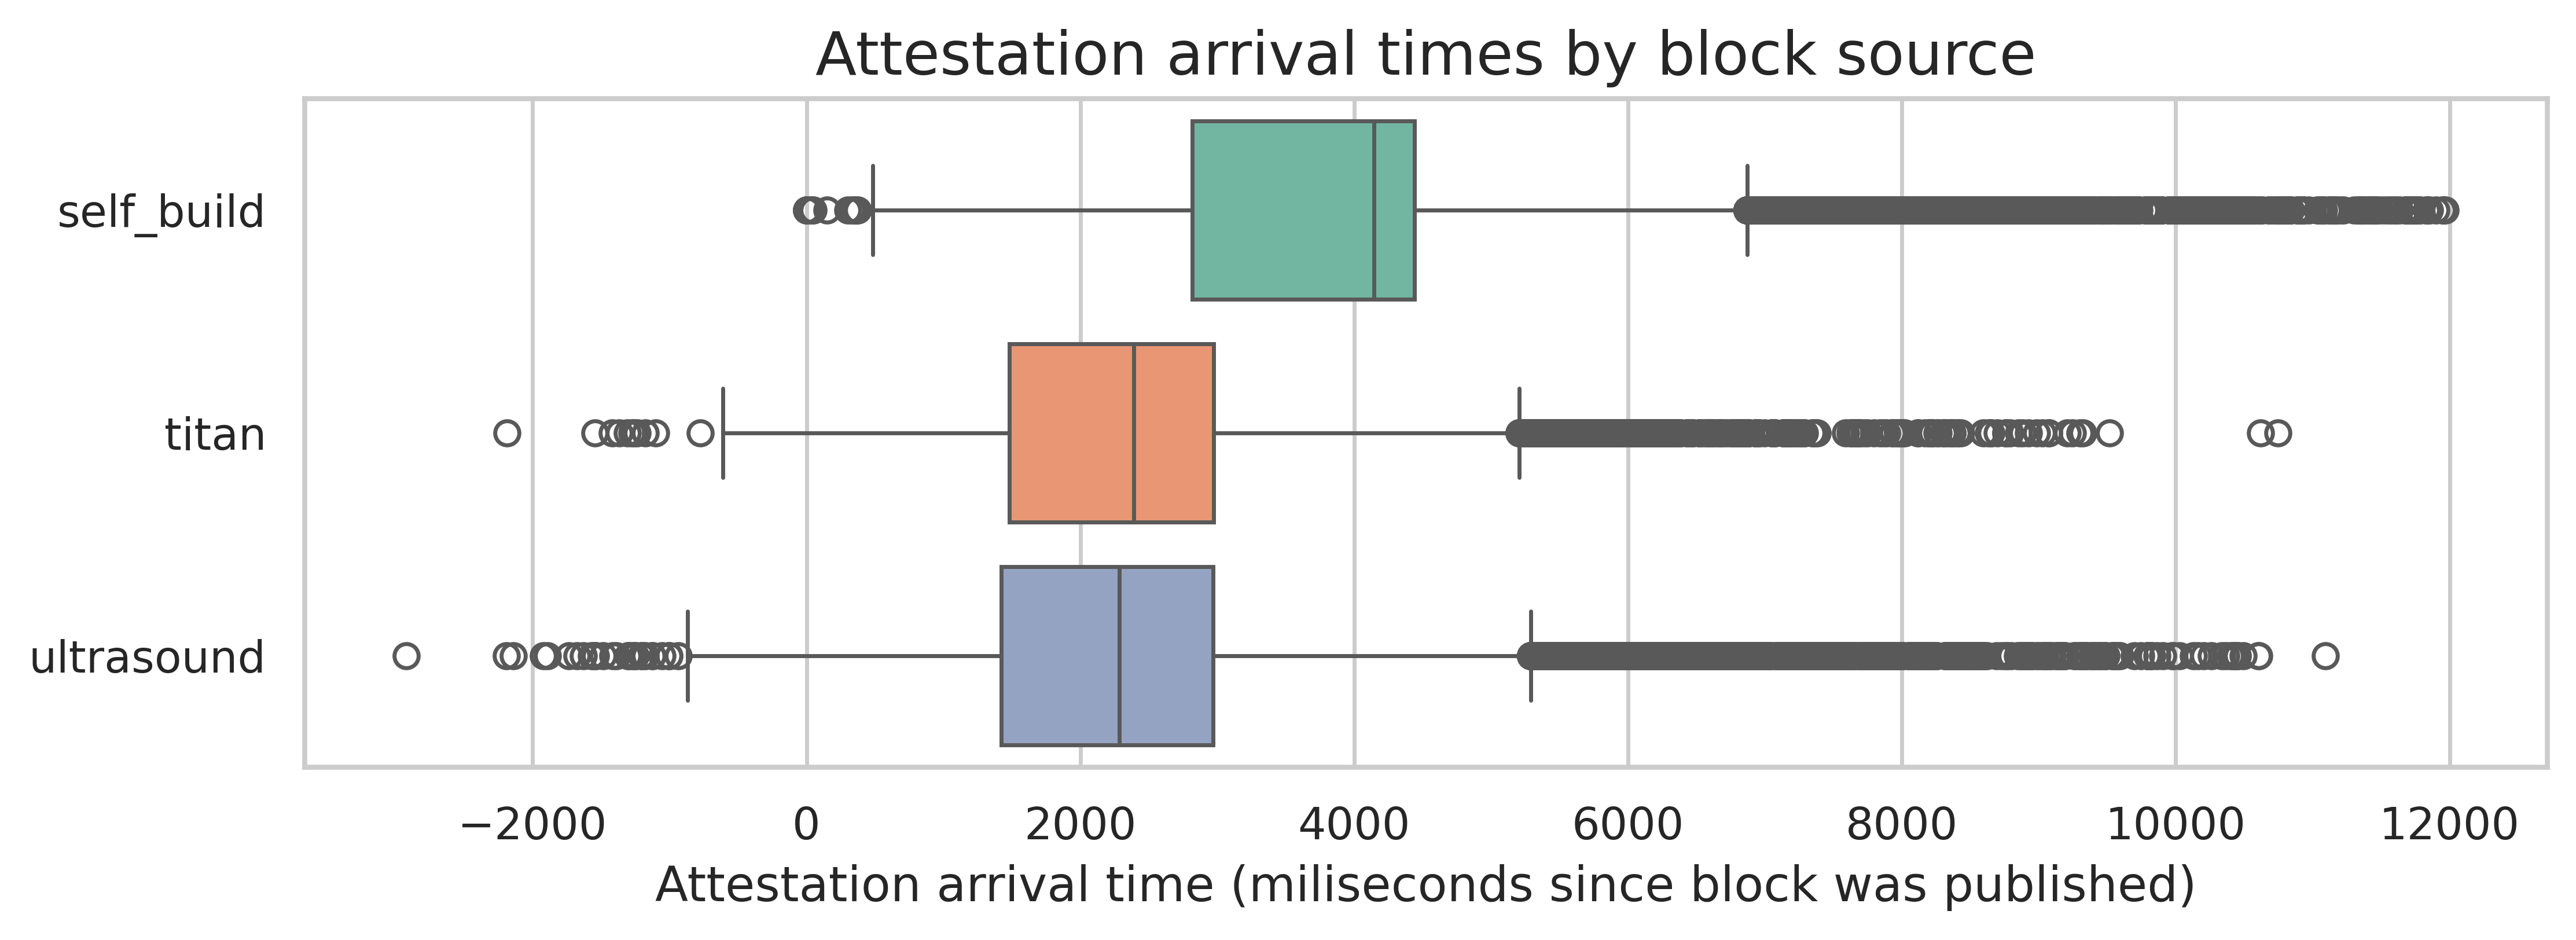

In [13]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("header_from"),
    x="net_atts_arrival_time_ms",
    y="header_from",
    hue="header_from",
    legend=False
)
plt.title("Attestation arrival times by block source")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since block was published)")
plt.show()

In [14]:
df[df["net_atts_arrival_time_ms"] < 0]["header_from"].value_counts()

header_from
ultrasound    100
titan          16
Name: count, dtype: int64

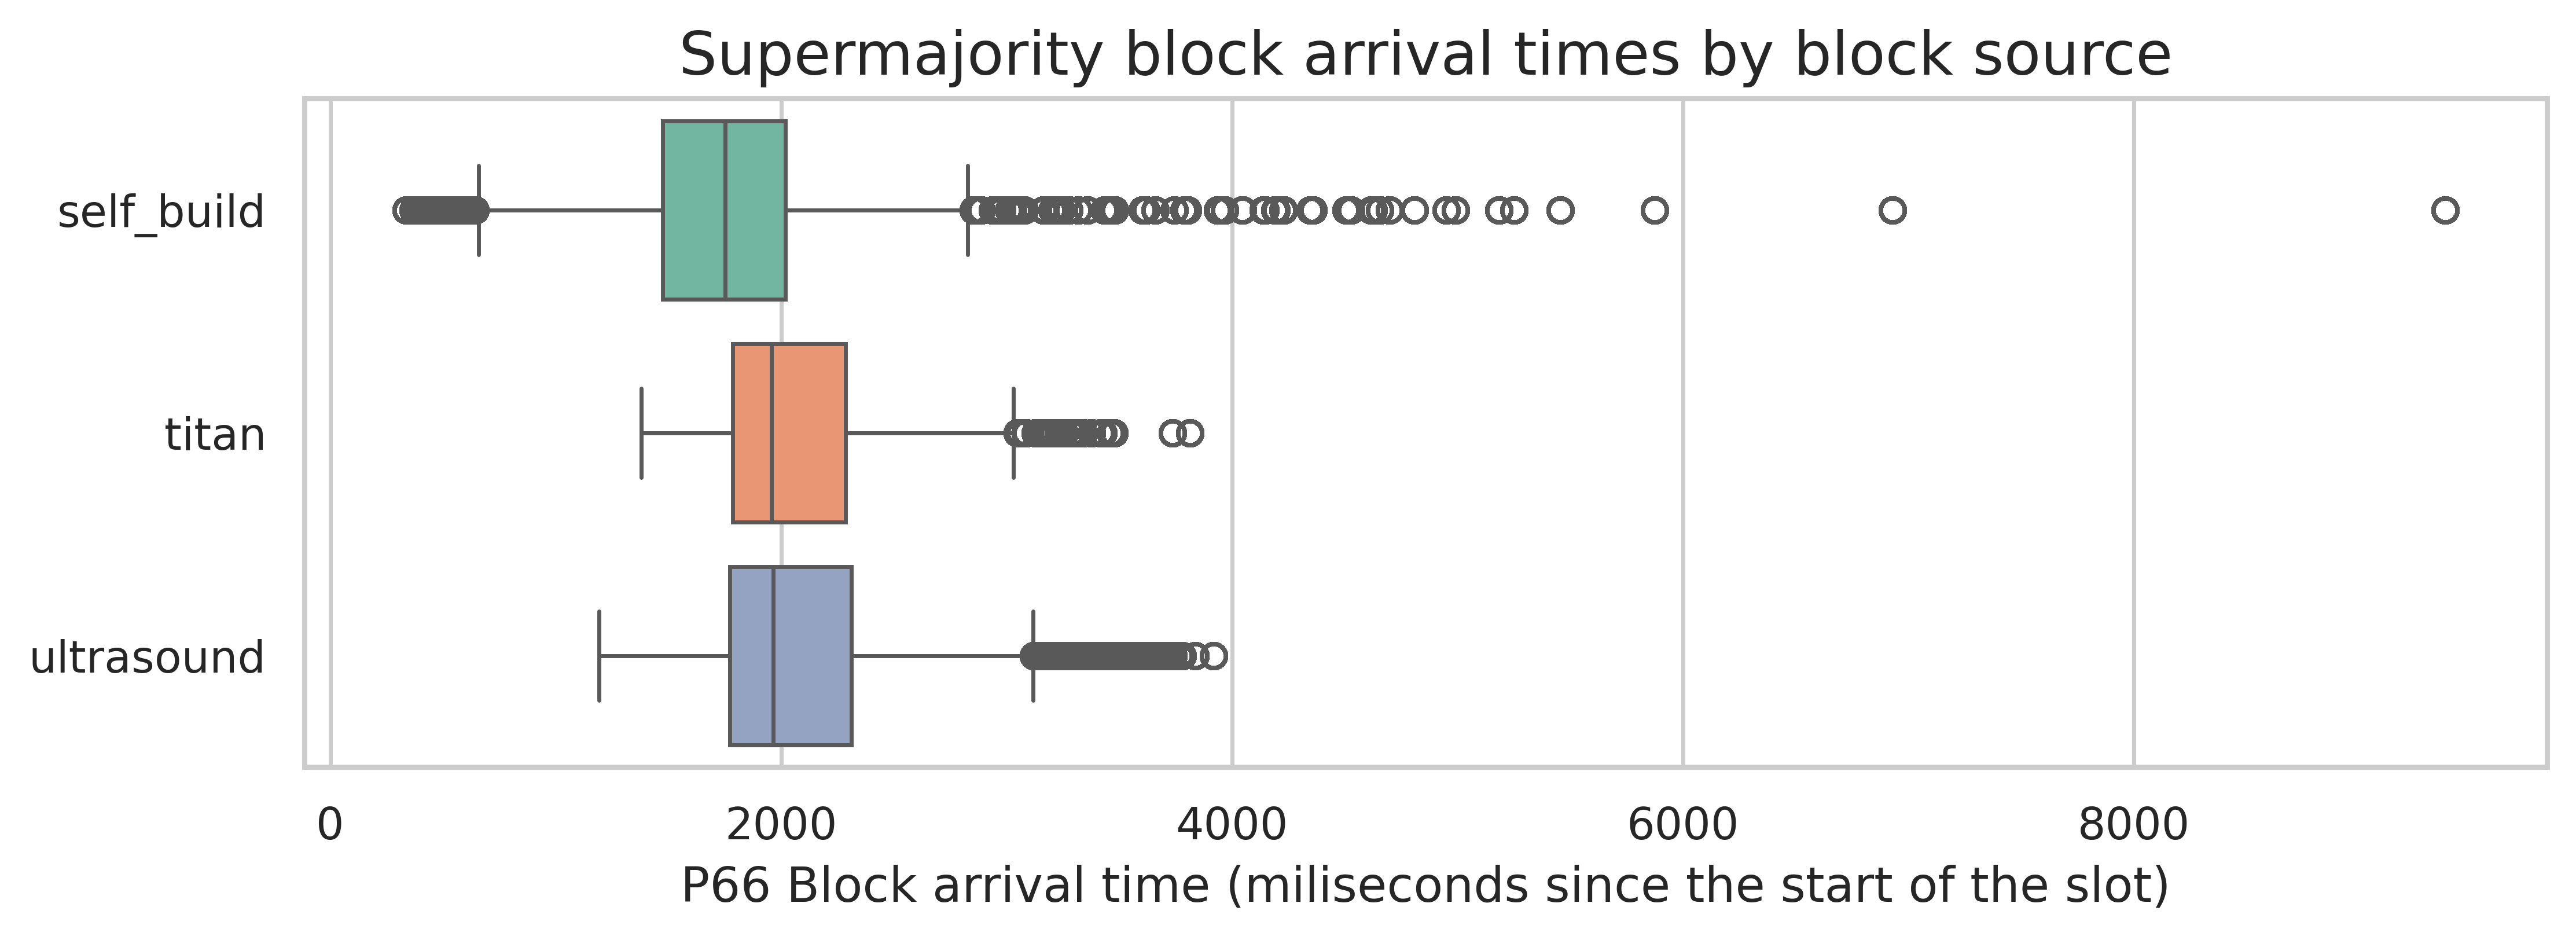

In [16]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("header_from"),
    x="p66_block_arrival_ms",
    y="header_from",
    hue="header_from",
    legend=False
)
plt.title("Supermajority block arrival times by block source")
plt.ylabel("")
plt.xlabel("P66 Block arrival time (miliseconds since the start of the slot)")
plt.show()

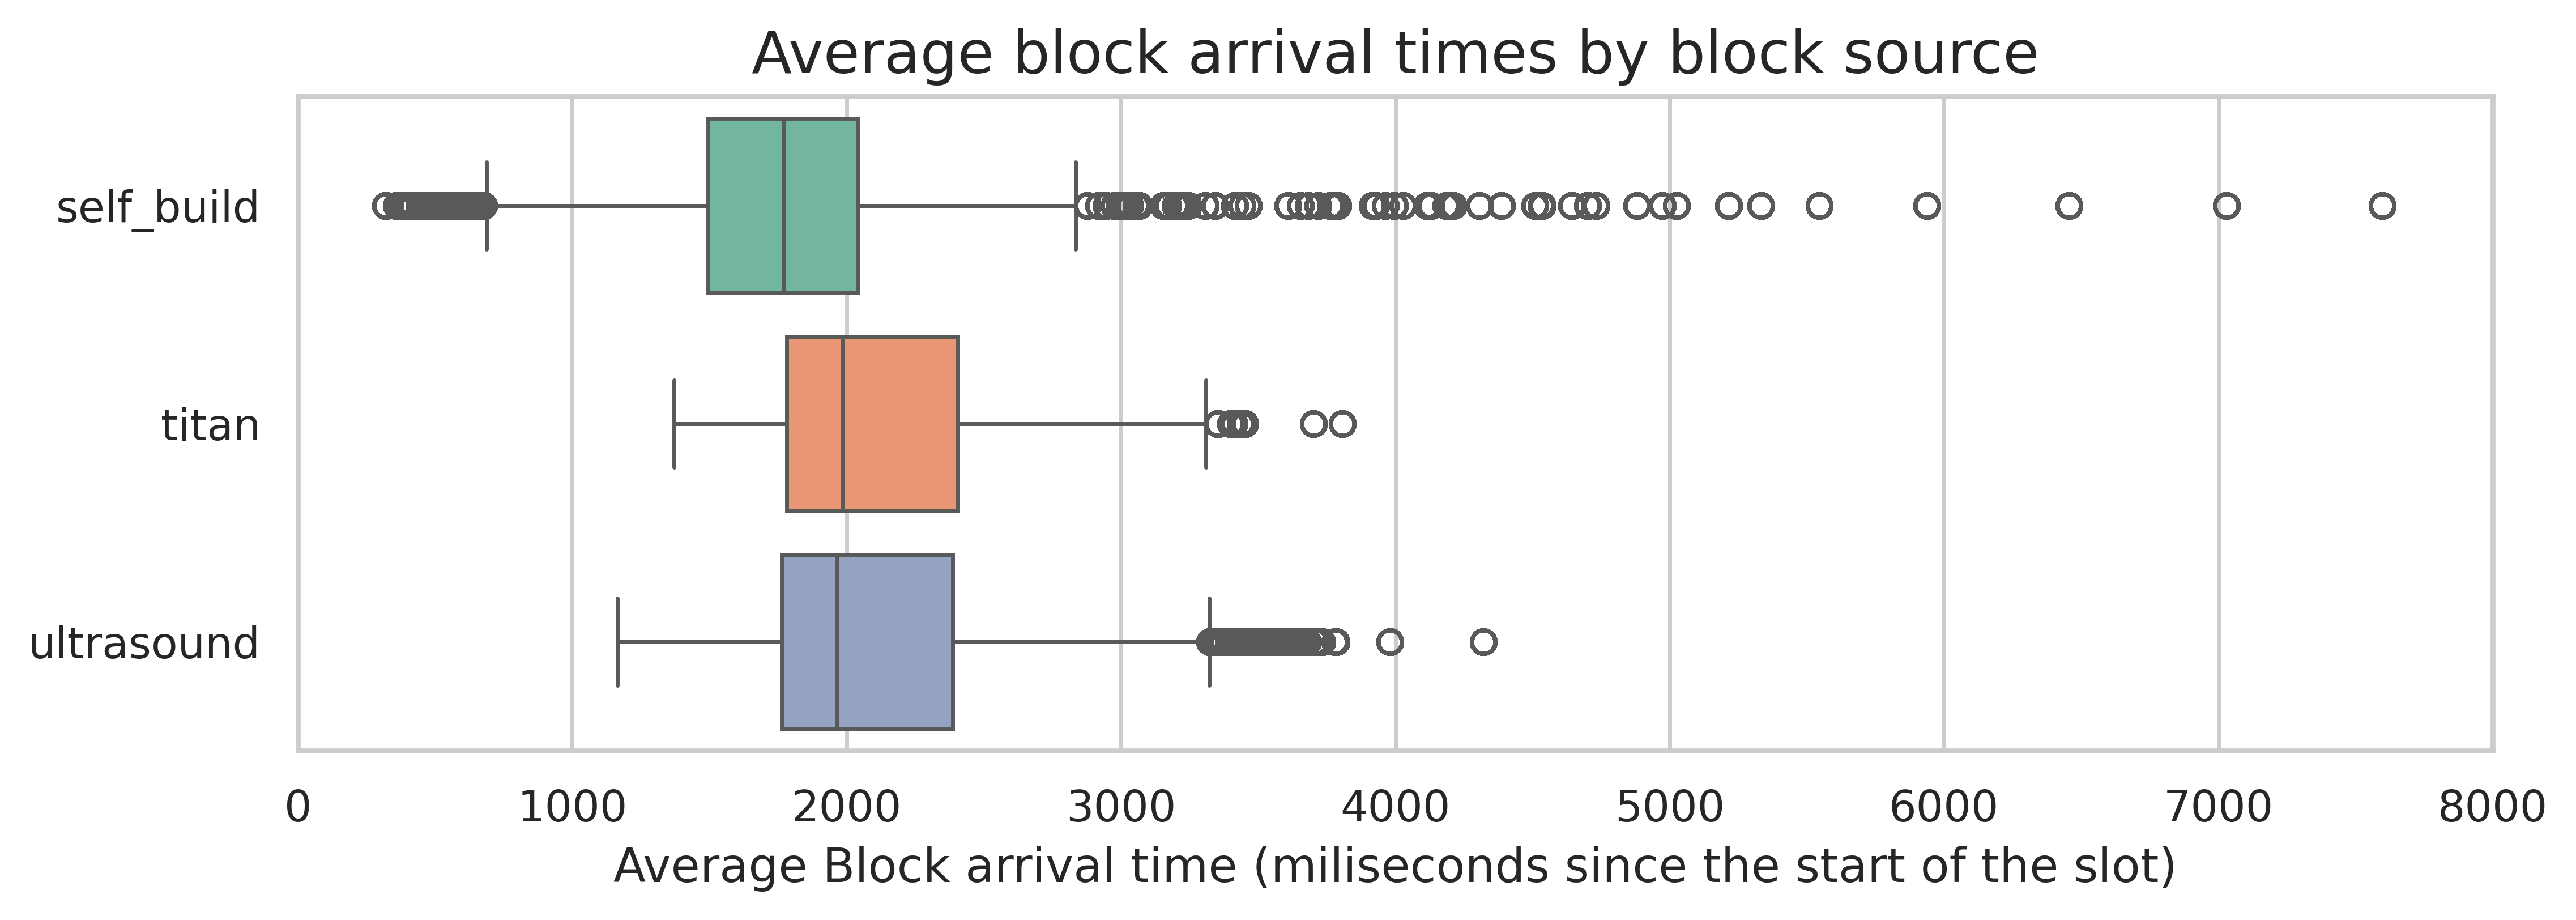

In [17]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("header_from"),
    x="avg_block_arrival_ms",
    y="header_from",
    hue="header_from",
    legend=False
)
plt.xlim(0,8000)
plt.title("Average block arrival times by block source")
plt.ylabel("")
plt.xlabel("Average Block arrival time (miliseconds since the start of the slot)")
plt.show()

### Arrival times by entity

In [18]:
entity_counts = df["entity"].value_counts()/len(df)
ent_df = df.merge(entity_counts, left_on="entity", right_index=True)
ent_df["entity"] = np.where(ent_df["count"]>0.01, ent_df["entity"], "other")
ent_df = ent_df.sort_values("count", ascending=False)

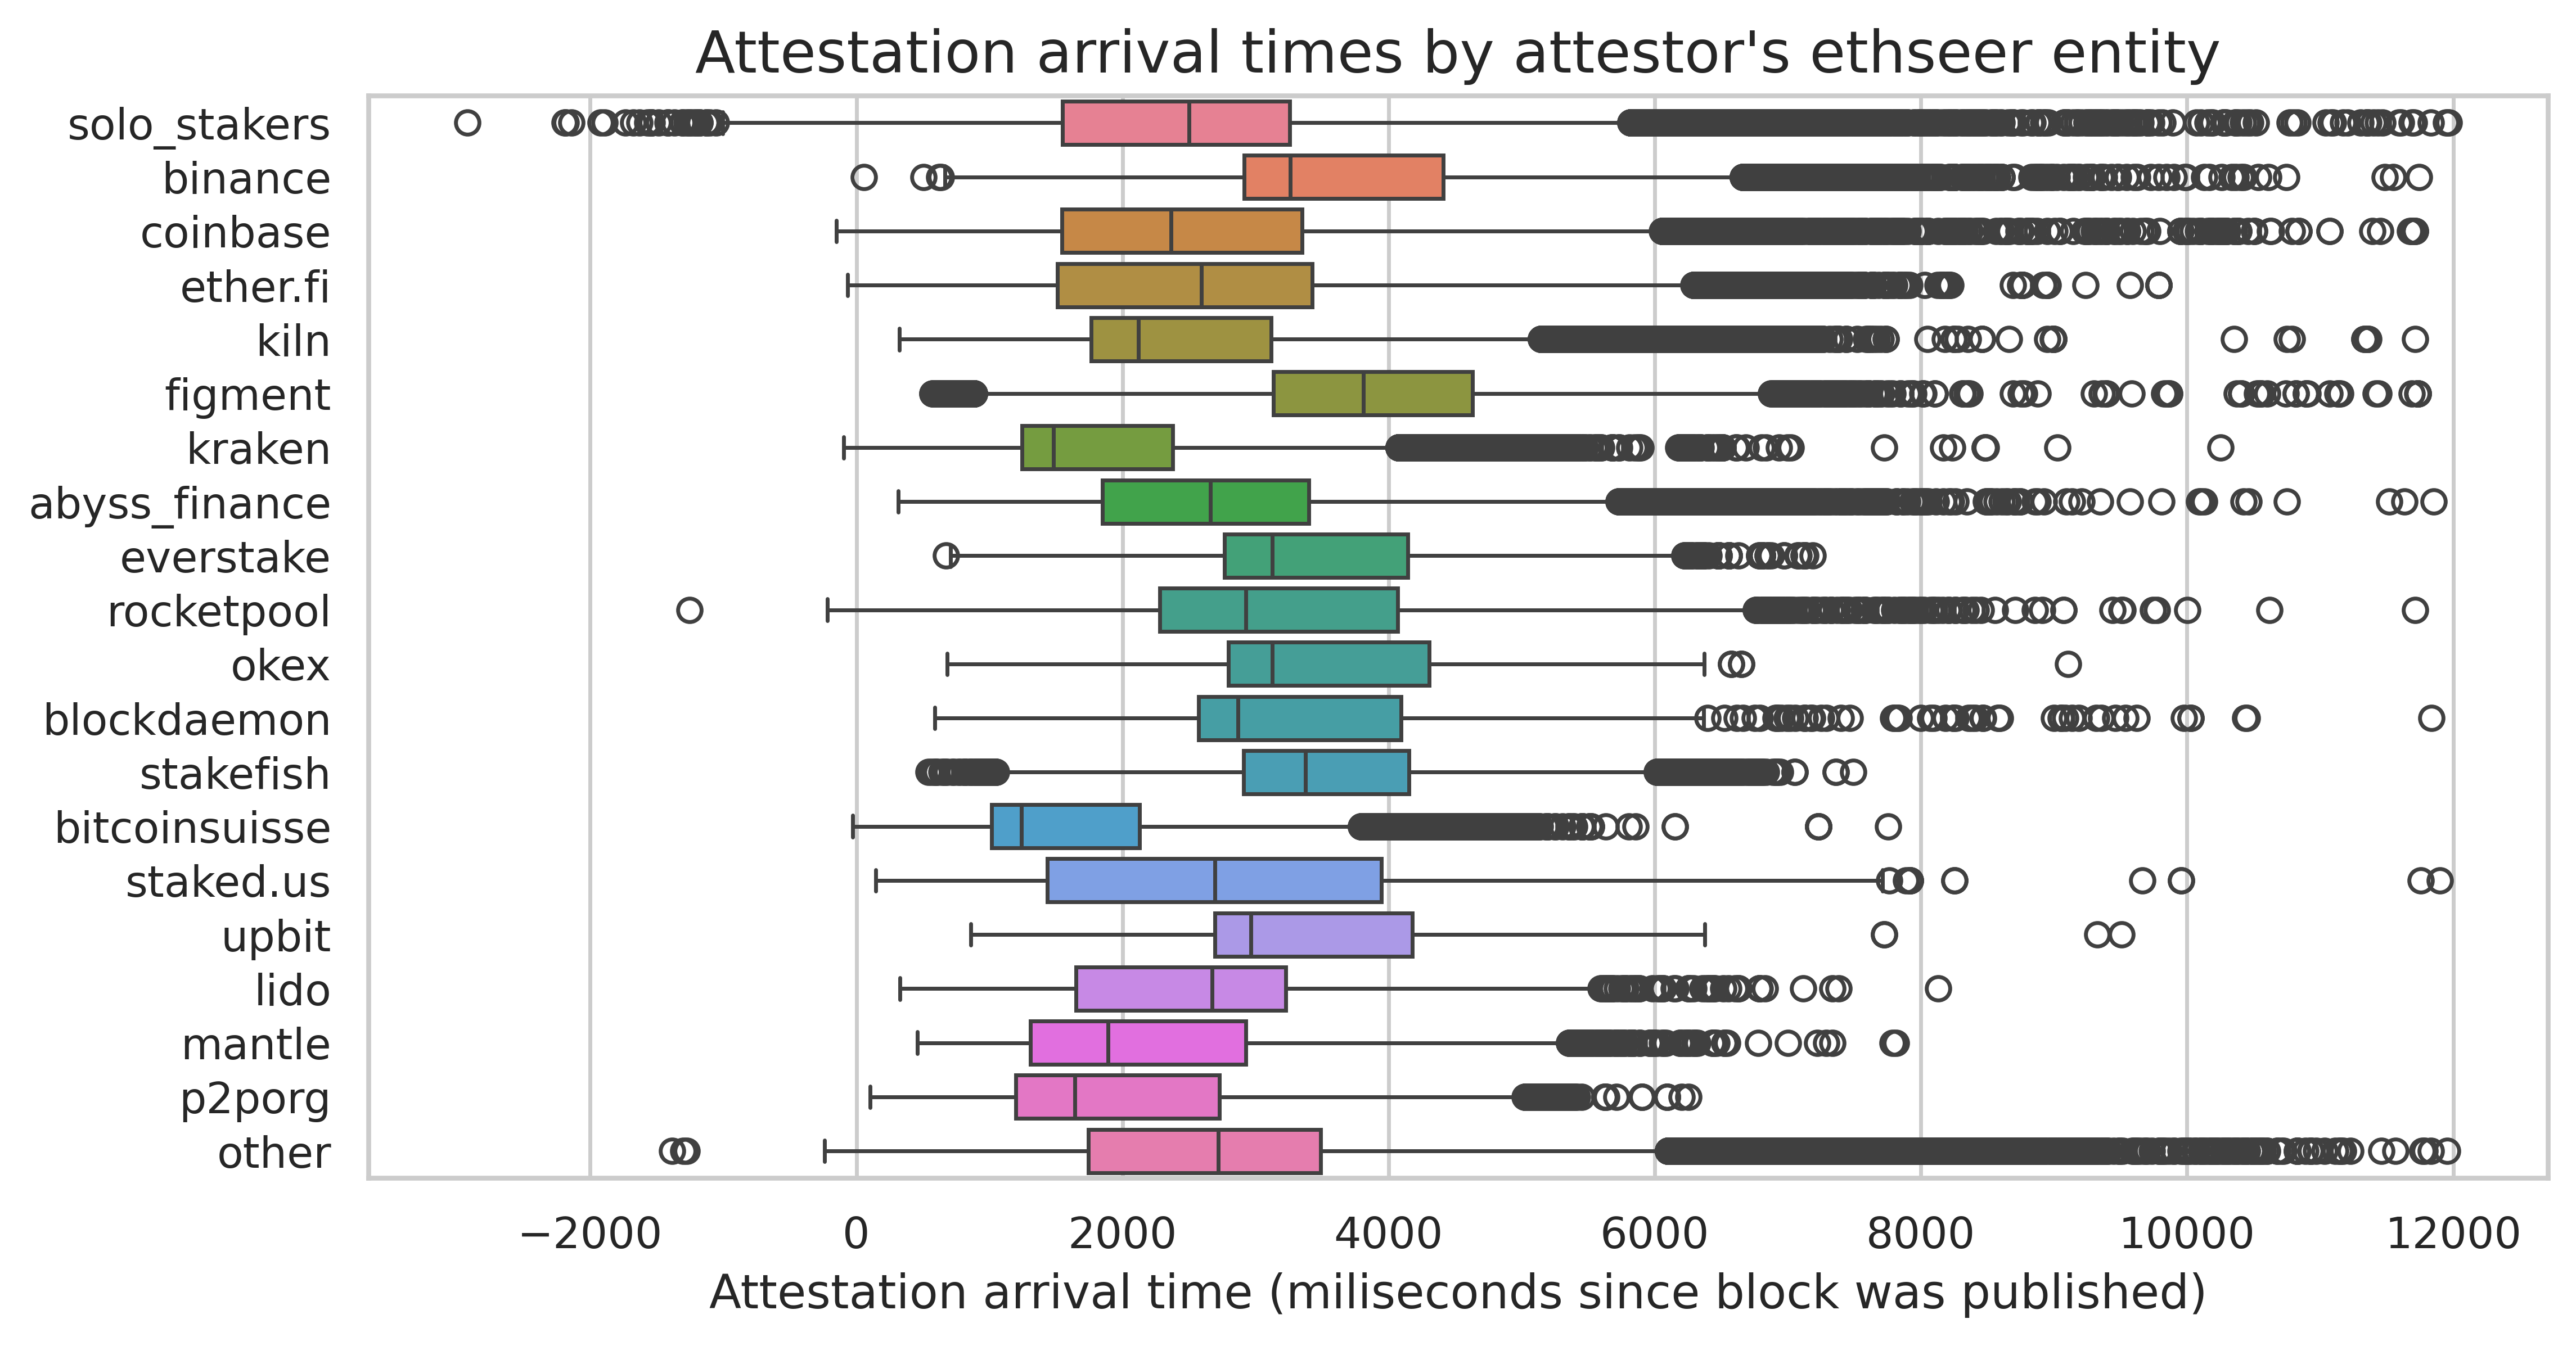

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=ent_df,
    x="net_atts_arrival_time_ms",
    y="entity",
    hue="entity",
    legend=False
)
plt.title("Attestation arrival times by attestor's ethseer entity")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since block was published)")
plt.show()

In [20]:
(ent_df.groupby("entity").size().sort_values(ascending=False)/len(ent_df)).head(20)

entity
other            0.394736
solo_stakers     0.084927
binance          0.084512
coinbase         0.070639
ether.fi         0.068646
kiln             0.043344
figment          0.036388
kraken           0.036287
abyss_finance    0.019240
everstake        0.018756
rocketpool       0.018370
okex             0.018248
blockdaemon      0.017669
stakefish        0.016545
bitcoinsuisse    0.013554
staked.us        0.013211
upbit            0.013100
lido             0.011203
mantle           0.010457
p2porg           0.010167
dtype: float64

In [21]:
ent_df[ent_df["net_atts_arrival_time_ms"] < 0]["entity"].value_counts().head(10)

entity
solo_stakers     78
other            18
coinbase         12
ether.fi          4
rocketpool        2
kraken            1
bitcoinsuisse     1
Name: count, dtype: int64

### Late arrivals (i.e. >4.5s)

In [22]:
late_df = df.copy()
late_df["is_late"] = late_df["net_atts_arrival_time_ms"] > 4500

sum(late_df["is_late"])/len(late_df)

0.08094094181662308

In [23]:
entity_counts = df["entity"].value_counts()/len(df)
ent_df = df.merge(entity_counts, left_on="entity", right_index=True)
ent_df["entity"] = np.where(ent_df["count"]>0.01, ent_df["entity"], "other")

temp_df = ent_df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "entity"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index="entity", values=0)
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])
temp_df["atts_rate"] = (temp_df[True] + temp_df[False])/len(df)
temp_df.sort_values("late_rate", ascending=False)

is_late,False,True,late_rate,atts_rate
entity,,,,
figment,74162,29827,0.286828,0.036388
stakefish,38028,9255,0.195736,0.016545
binance,198430,43085,0.178395,0.084512
staked.us,32131,5623,0.148938,0.013211
everstake,48131,5469,0.102034,0.018756
ether.fi,179033,17141,0.087377,0.068646
coinbase,184433,17437,0.086377,0.070639
rocketpool,48245,4253,0.081013,0.018370
okex,48616,3533,0.067748,0.018248


In [24]:
entity_counts = df["entity"].value_counts()/len(df)
temp_ent_df = df.merge(entity_counts, left_on="entity", right_index=True)
temp_ent_df["entity"] = np.where(temp_ent_df["count"]>0.001, temp_ent_df["entity"], "other")

temp_df = temp_ent_df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "entity"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index="entity", values=0)
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])
temp_df["atts_rate"] = (temp_df[True] + temp_df[False])/len(df)
temp_df[temp_df["late_rate"]>temp_df["atts_rate"]].sort_values("late_rate", ascending=False)

is_late,False,True,late_rate,atts_rate
entity,,,,
coinspot,6583,4771,0.420204,0.003973
figment_lido,12208,6820,0.358419,0.006658
figment,74162,29827,0.286828,0.036388
whale_0x8914,3657,1268,0.257462,0.001723
piertwo,3708,1233,0.249545,0.001729
...,...,...,...,...
revolut,5085,33,0.006448,0.001791
xhash,3353,17,0.005045,0.001179
hashhub,3650,15,0.004093,0.001282


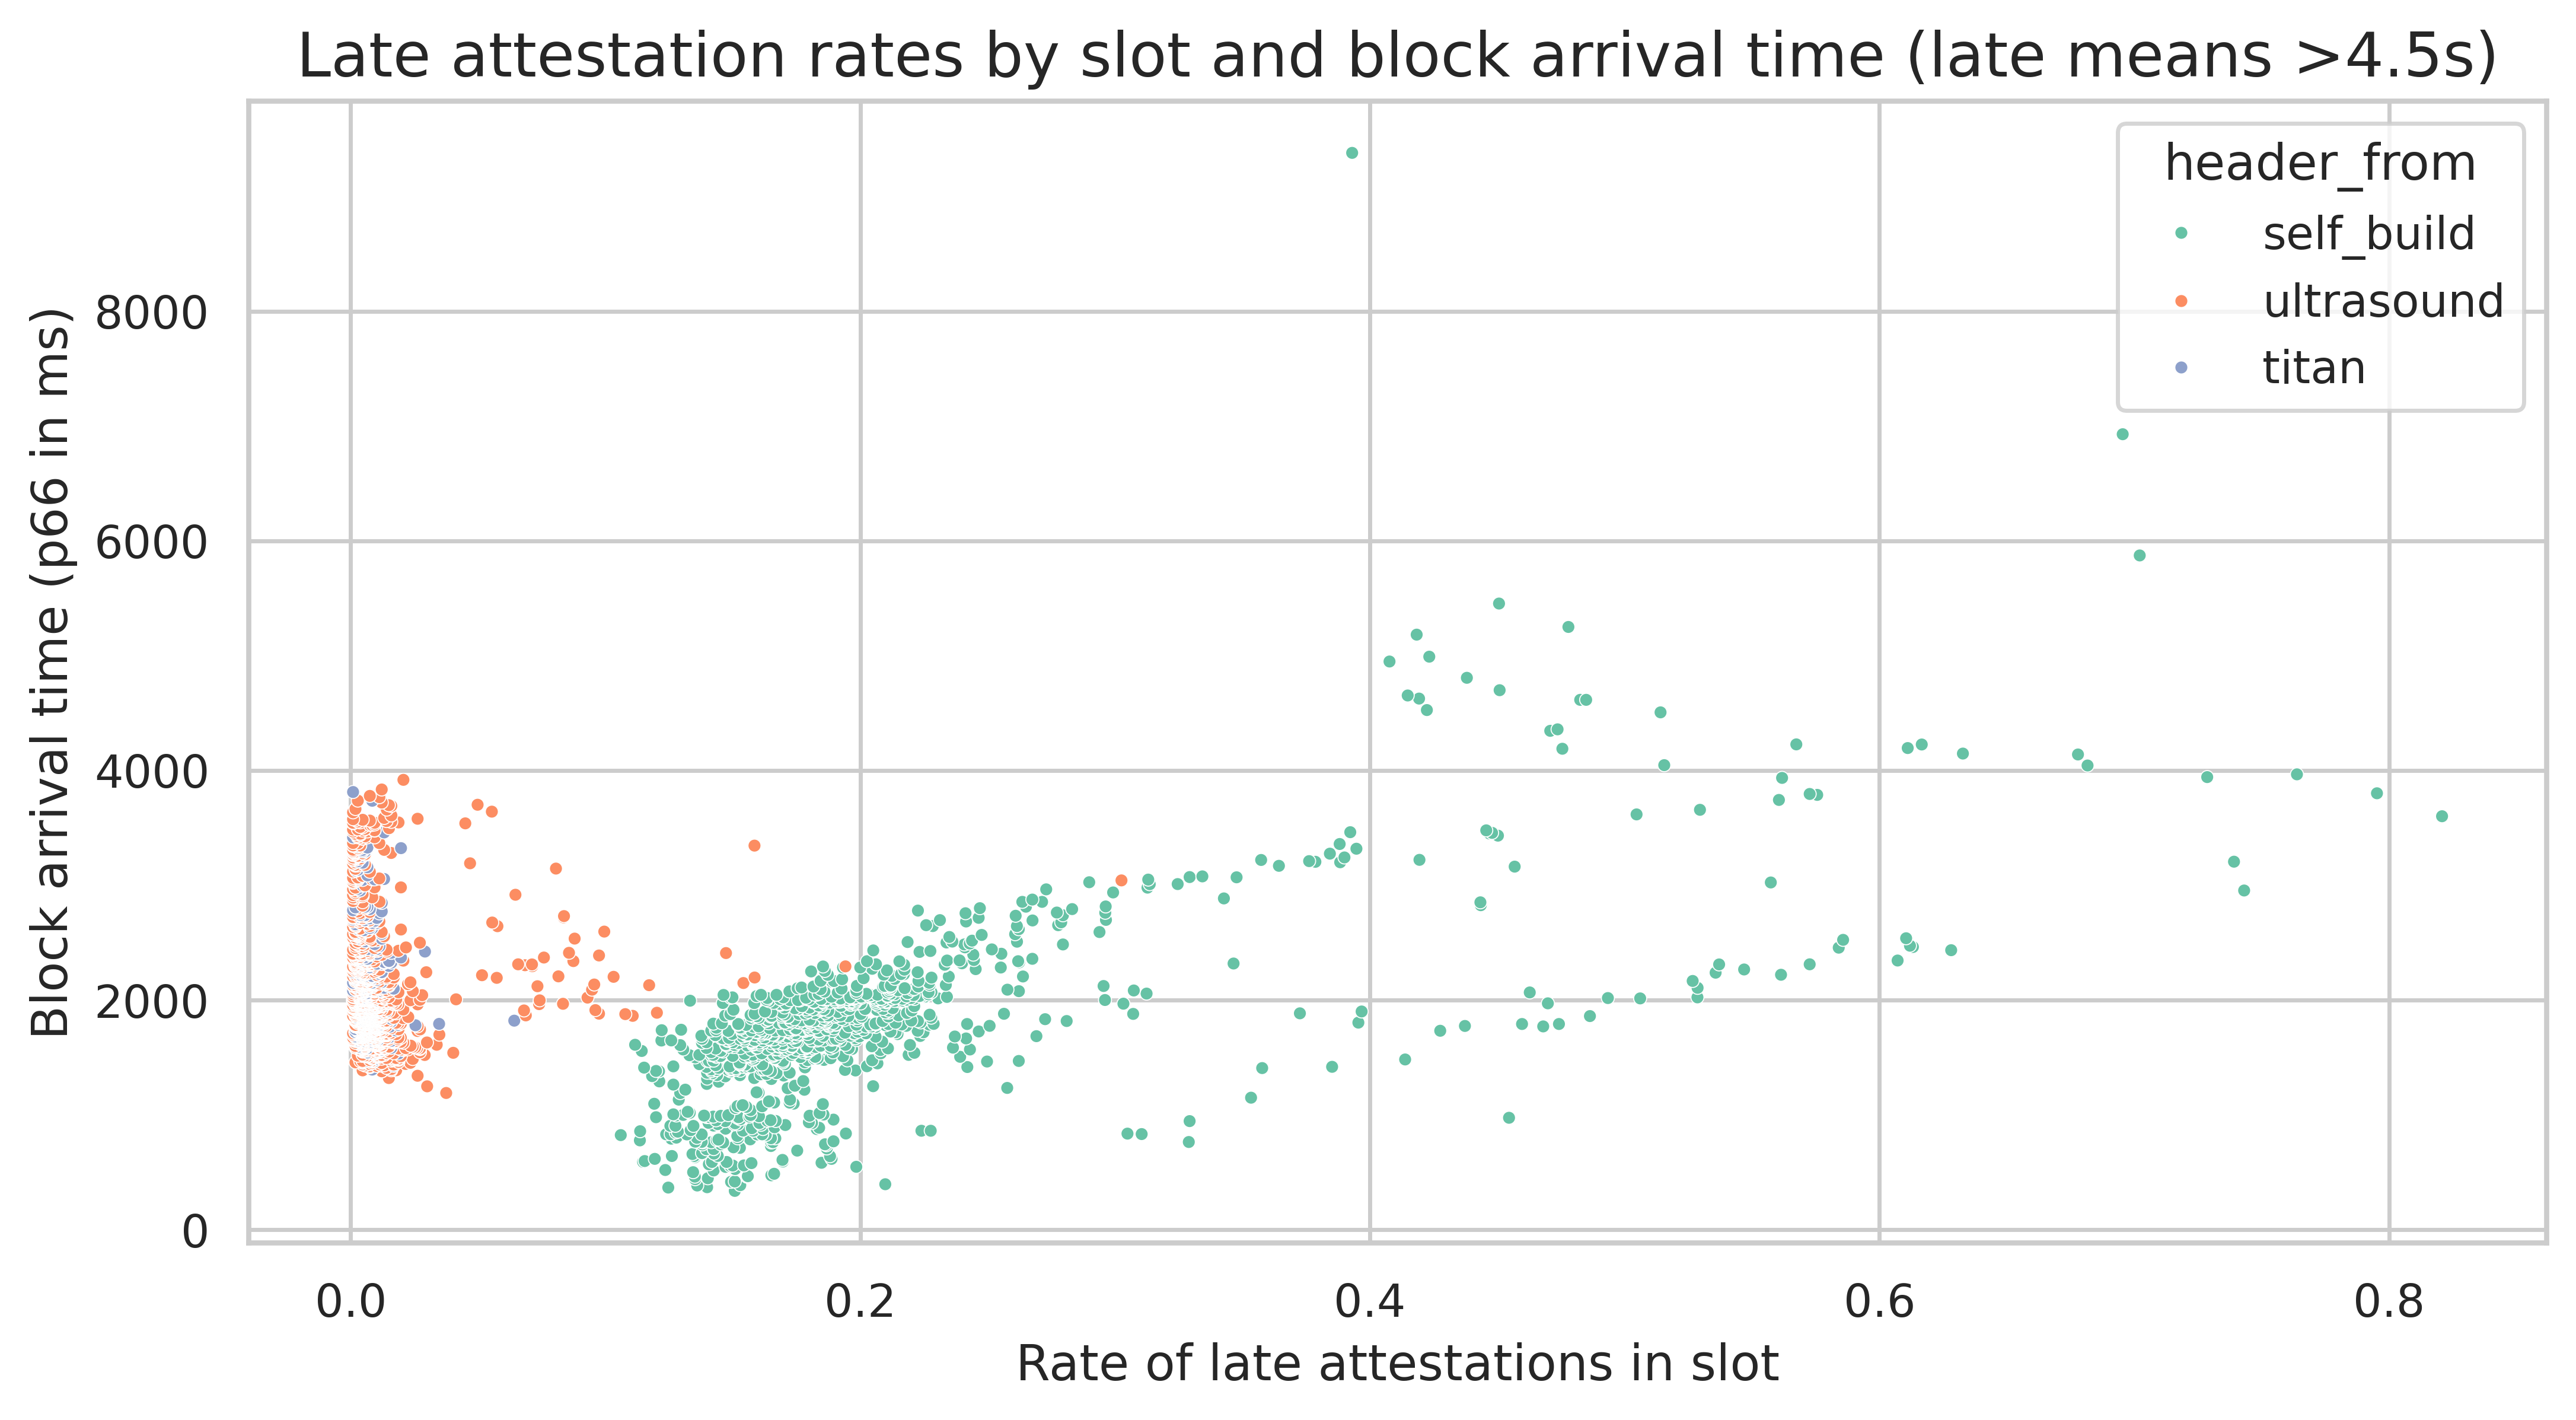

In [25]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot","p66_block_arrival_ms", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","p66_block_arrival_ms", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])


plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("p66_block_arrival_ms"),
    x="late_rate",
    y="p66_block_arrival_ms",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and block arrival time (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Block arrival time (p66 in ms)")

plt.show()

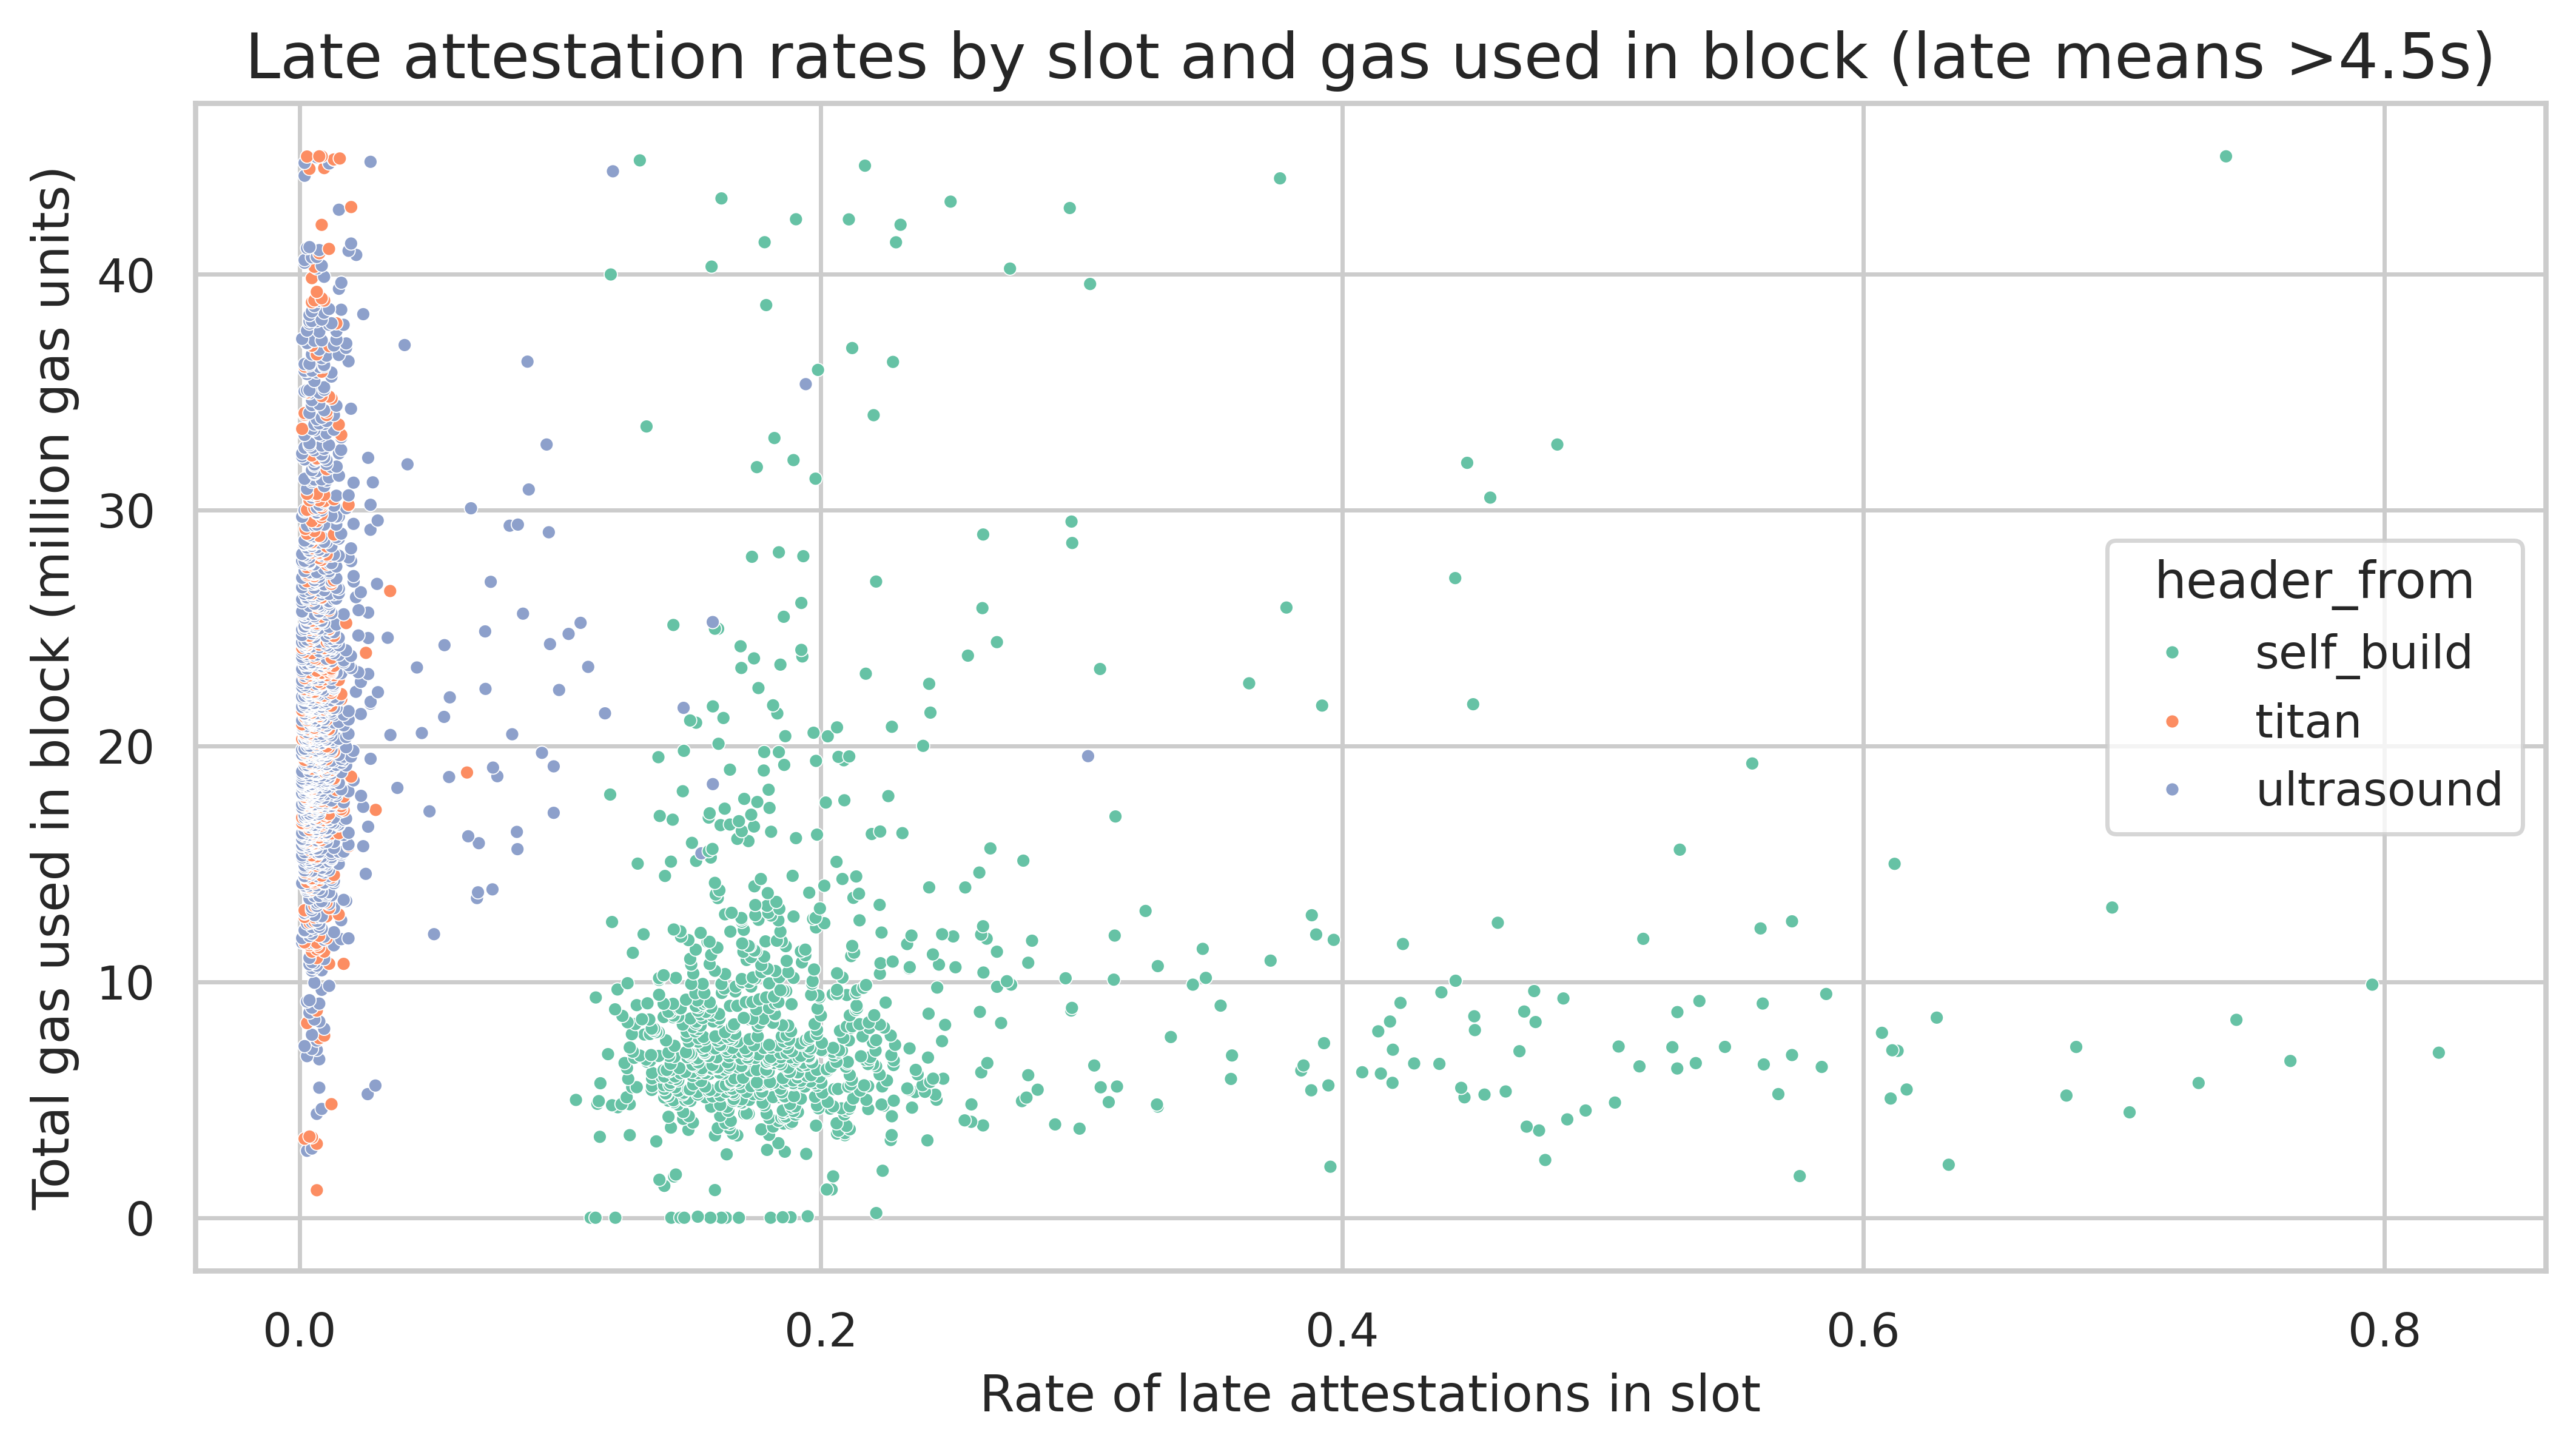

In [26]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot", "block_gas_used", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","block_gas_used", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])
temp_df["block_gas_used"] = temp_df["block_gas_used"]/1000000


plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("block_gas_used"),
    x="late_rate",
    y="block_gas_used",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and gas used in block (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Total gas used in block (million gas units)")

plt.show()

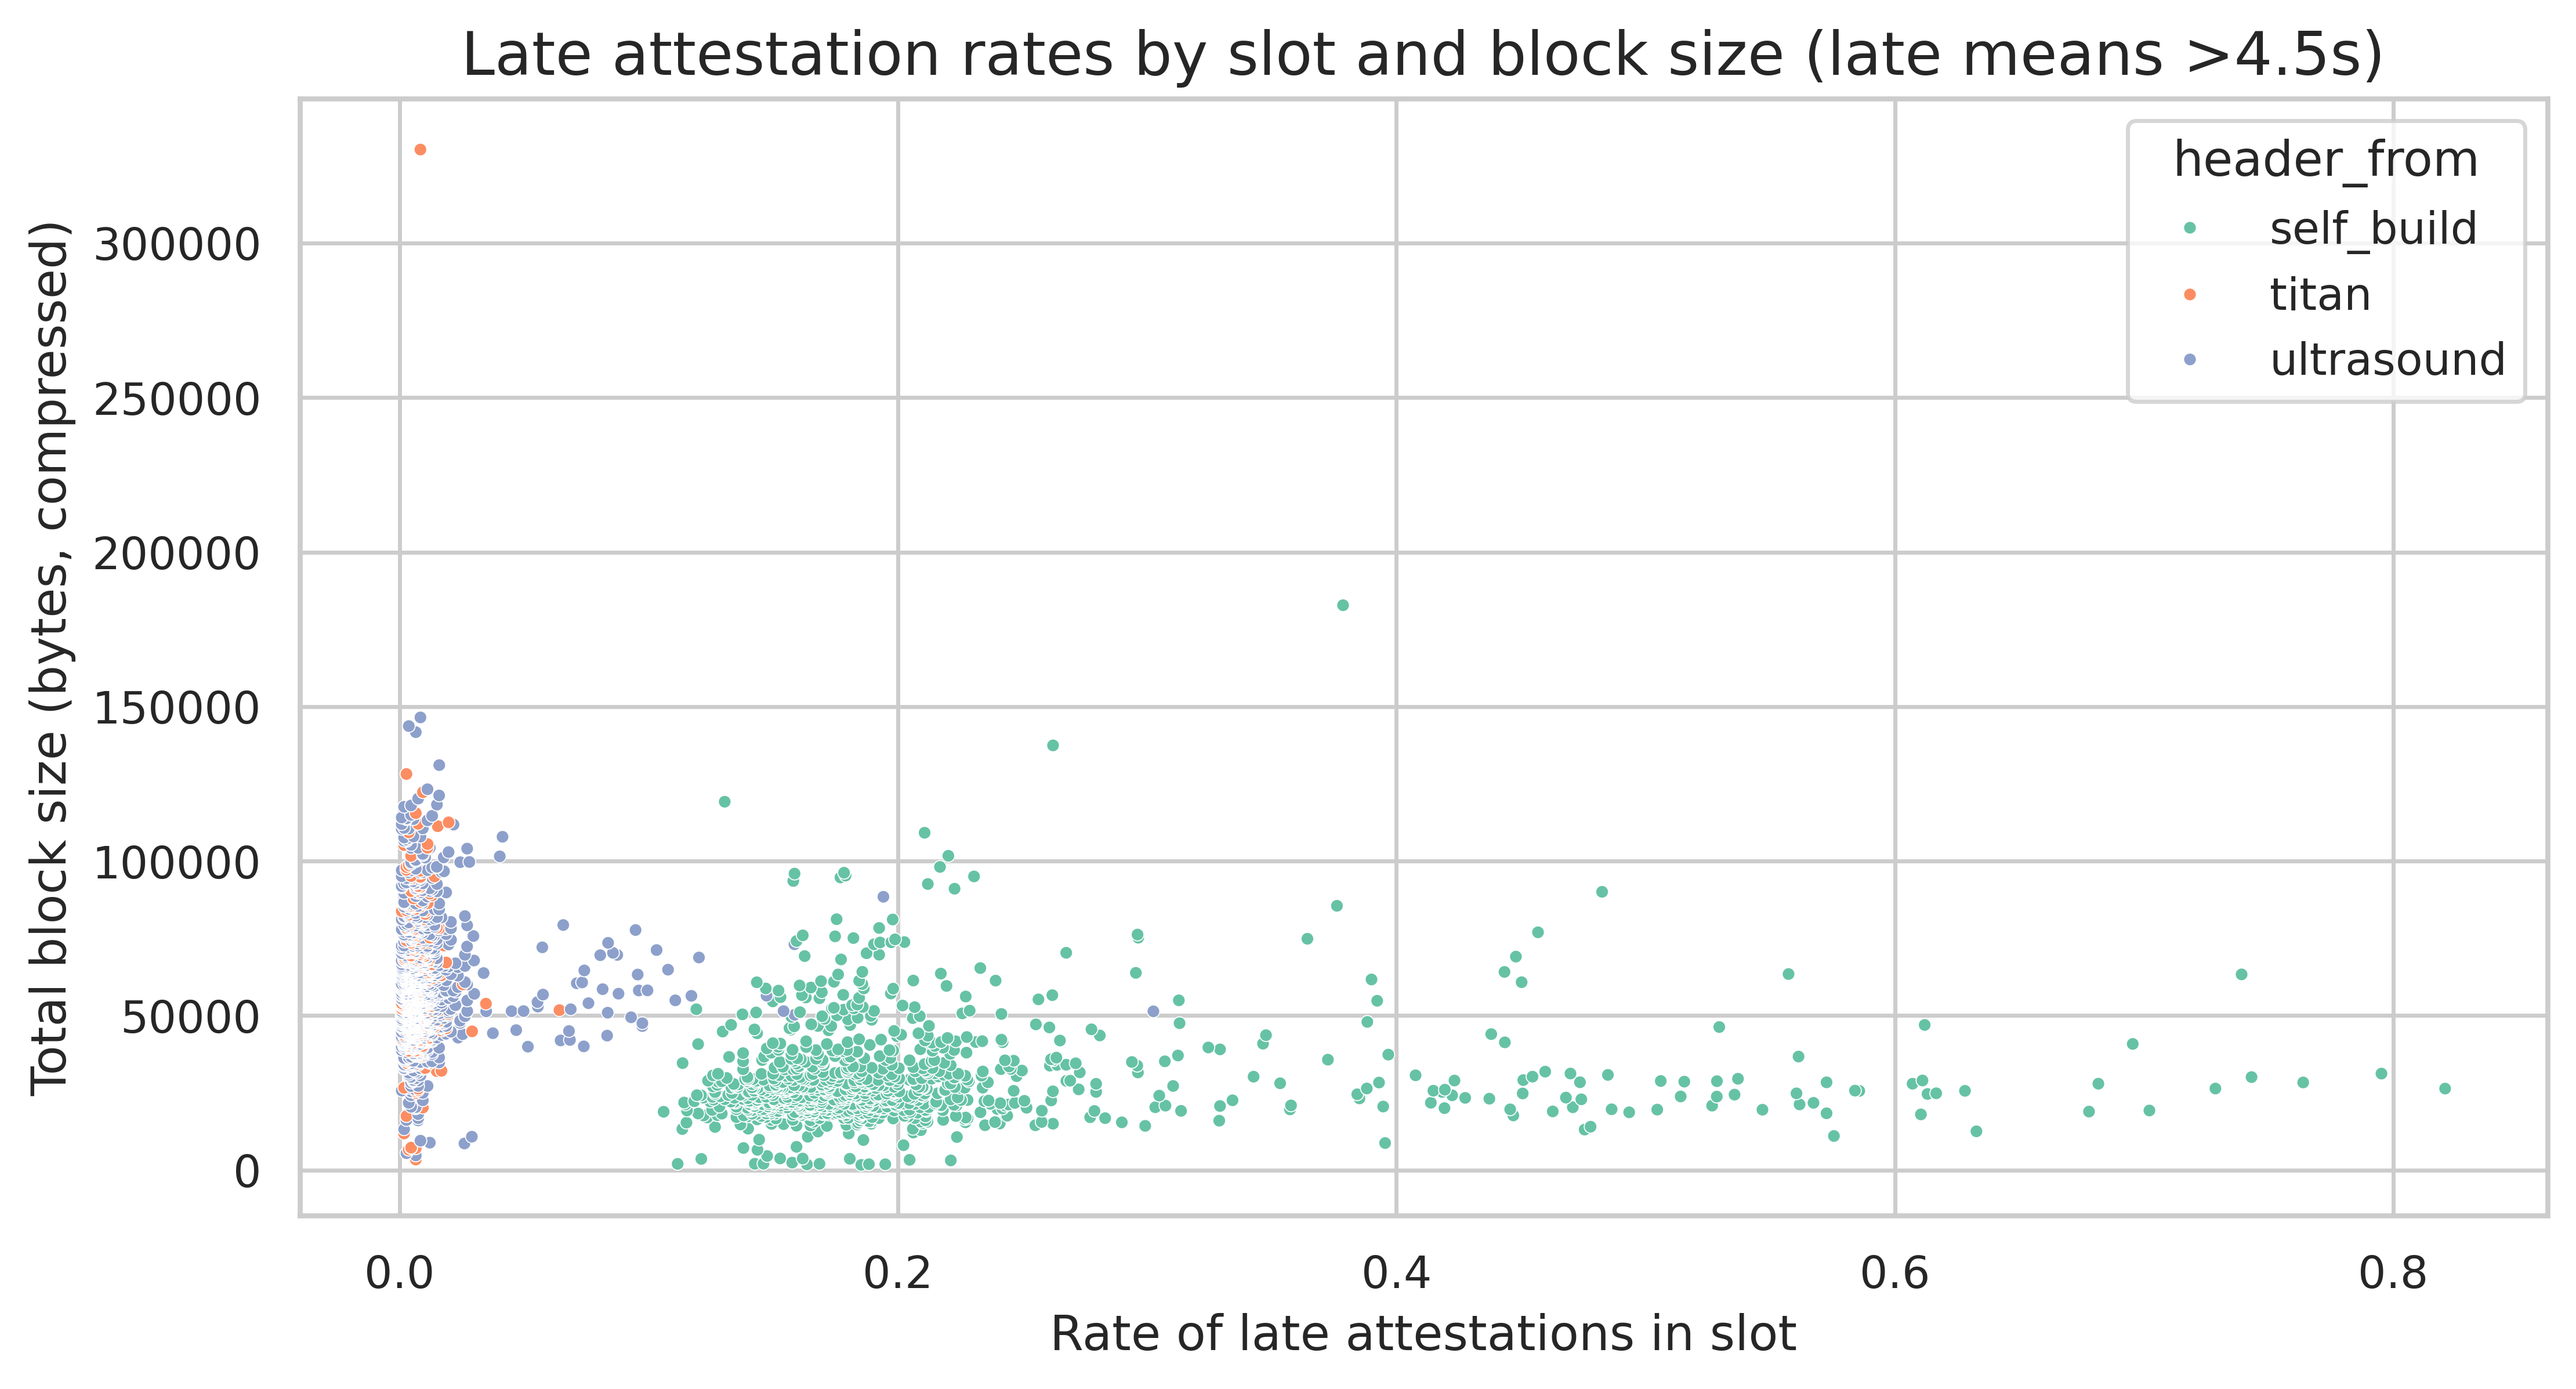

In [27]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot","block_total_bytes_compressed", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","block_total_bytes_compressed", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])


plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("block_total_bytes_compressed"),
    x="late_rate",
    y="block_total_bytes_compressed",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and block size (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Total block size (bytes, compressed)")

plt.show()

## 4. Classifiers outputs and feature analysis

In [6]:
# Load X, y, and feature names
X = np.load(os.path.join(model_out_dir, "train_data", "X.npy"))
y = np.load(os.path.join(model_out_dir, "train_data", "y.npy"))
feature_names = np.load(
    os.path.join(model_out_dir, "train_data", "feature_names.npy"), allow_pickle=True
).tolist()

### Logit regression (statsmodel)

In [7]:
# Convert X to DataFrame with feature names
X_df = pd.DataFrame(X, columns=feature_names)
X_with_intercept_df = sm.add_constant(X_df)  # adds intercept

logit_model = sm.Logit(y, X_with_intercept_df)
result = logit_model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.187660
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:              2857659
Model:                          Logit   Df Residuals:                  2857630
Method:                           MLE   Df Model:                           28
Date:                Fri, 08 Aug 2025   Pseudo R-squ.:                  0.3323
Time:                        08:58:17   Log-Likelihood:            -5.3627e+05
converged:                       True   LL-Null:                   -8.0320e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.9915   4.35e+04  -6.87e-05      1.000   -8.53e+04    8.53e+04
p95_block_arrival_ms            -0.0063      0.003     -2.231      0.026      -0.012      -0.001
p66_block_arrival_ms             0.3412      0.002    164.237      0.000       0.337       0.345
avg_block_arrival_ms            -0.0044      0.003     -1.453      0.146      -0.010       0.002
block_total_bytes_compressed    -0.0621      0.006    -10.046      0.000      -0.074      -0.050
block_proposer_index             0.0309      0.002     12.383      0.000       0.026       0.036
block_gas_used                   0.0796      0.006     14.332      0.000       0.069       0.090
block_tx_count                  -0.0313      0.006     -5.198      0.000      -0.043      -0.020
header_from_self_build           1.5834   1.14e+05   1.39e-05      1.000   -2.23e+05    2.23e+05
header_from_titan               -2.4488   1.14e+05  -2.15e-05      1.000   -2.23e+05    2.23e+05
header_from_ultrasound          -2.1262   1.14e+05  -1.87e-05      1.000   -2.23e+05    2.23e+05
entity_abyss_finance            -0.2701   1.21e+05  -2.23e-06      1.000   -2.37e+05    2.37e+05
entity_binance                   1.3844   1.21e+05   1.14e-05      1.000   -2.37e+05    2.37e+05
entity_bitcoinsuisse            -1.9004   1.21e+05  -1.57e-05      1.000   -2.37e+05    2.37e+05
entity_blockdaemon              -2.3986   1.21e+05  -1.98e-05      1.000   -2.37e+05    2.37e+05
entity_coinbase                  0.2739   1.21e+05   2.26e-06      1.000   -2.37e+05    2.37e+05
entity_ether.fi                  0.2975   1.21e+05   2.46e-06      1.000   -2.37e+05    2.37e+05
entity_everstake                 0.5053   1.21e+05   4.17e-06      1.000   -2.37e+05    2.37e+05
entity_figment                   2.3939   1.21e+05   1.98e-05      1.000   -2.37e+05    2.37e+05
entity_kiln                     -0.4786   1.21e+05  -3.95e-06      1.000   -2.37e+05    2.37e+05
entity_kraken                   -1.8424   1.21e+05  -1.52e-05      1.000   -2.37e+05    2.37e+05
entity_lido                     -1.1323   1.21e+05  -9.35e-06      1.000   -2.37e+05    2.37e+05
entity_mantle                   -0.3426   1.21e+05  -2.83e-06      1.000   -2.37e+05    2.37e+05
entity_okex                     -0.0367   1.21e+05  -3.03e-07      1.000   -2.37e+05    2.37e+05
entity_other                    -0.1972   1.21e+05  -1.63e-06      1.000   -2.37e+05    2.37e+05
entity_p2porg                   -0.8247   1.21e+05  -6.81e-06      1.000   -2.37e+05    2.37e+05
entity_rocketpool                0.1799   1.21e+05   1.49e-06      1.000   -2.37e+05    2.37e+05
entity_solo_stakers             -0.3917   1.21e+05  -3.23e-06      1.000   -2.37e+05    2.37e+05
entity_staked.us                 1.0714   1.21e+05   8.85e-06      1.000   -2.37e+05    2.37e+05
entity_stakefish                 1.5439   1.21e+05   1.27e-05      1.000   -2.37e+05    2.37e+05
entity_upbit                    -0.8266 

### Random Forest Classifier

In [31]:
# Load model
rf_model_name = "RandomForestClassifier"
model_path = os.path.join(model_out_dir, rf_model_name, "model.pkl")
with open(model_path, "rb") as f:
    rf_model = pickle.load(f)

# Evaluate the model
print(
    classification_report(
        y, rf_model.predict(X), target_names=["on-time", "late"], digits=3
    )
)

              precision    recall  f1-score   support

     on-time      0.919     1.000     0.958   2626348
        late      0.000     0.000     0.000    231311

    accuracy                          0.919   2857659
   macro avg      0.460     0.500     0.479   2857659
weighted avg      0.845     0.919     0.880   2857659



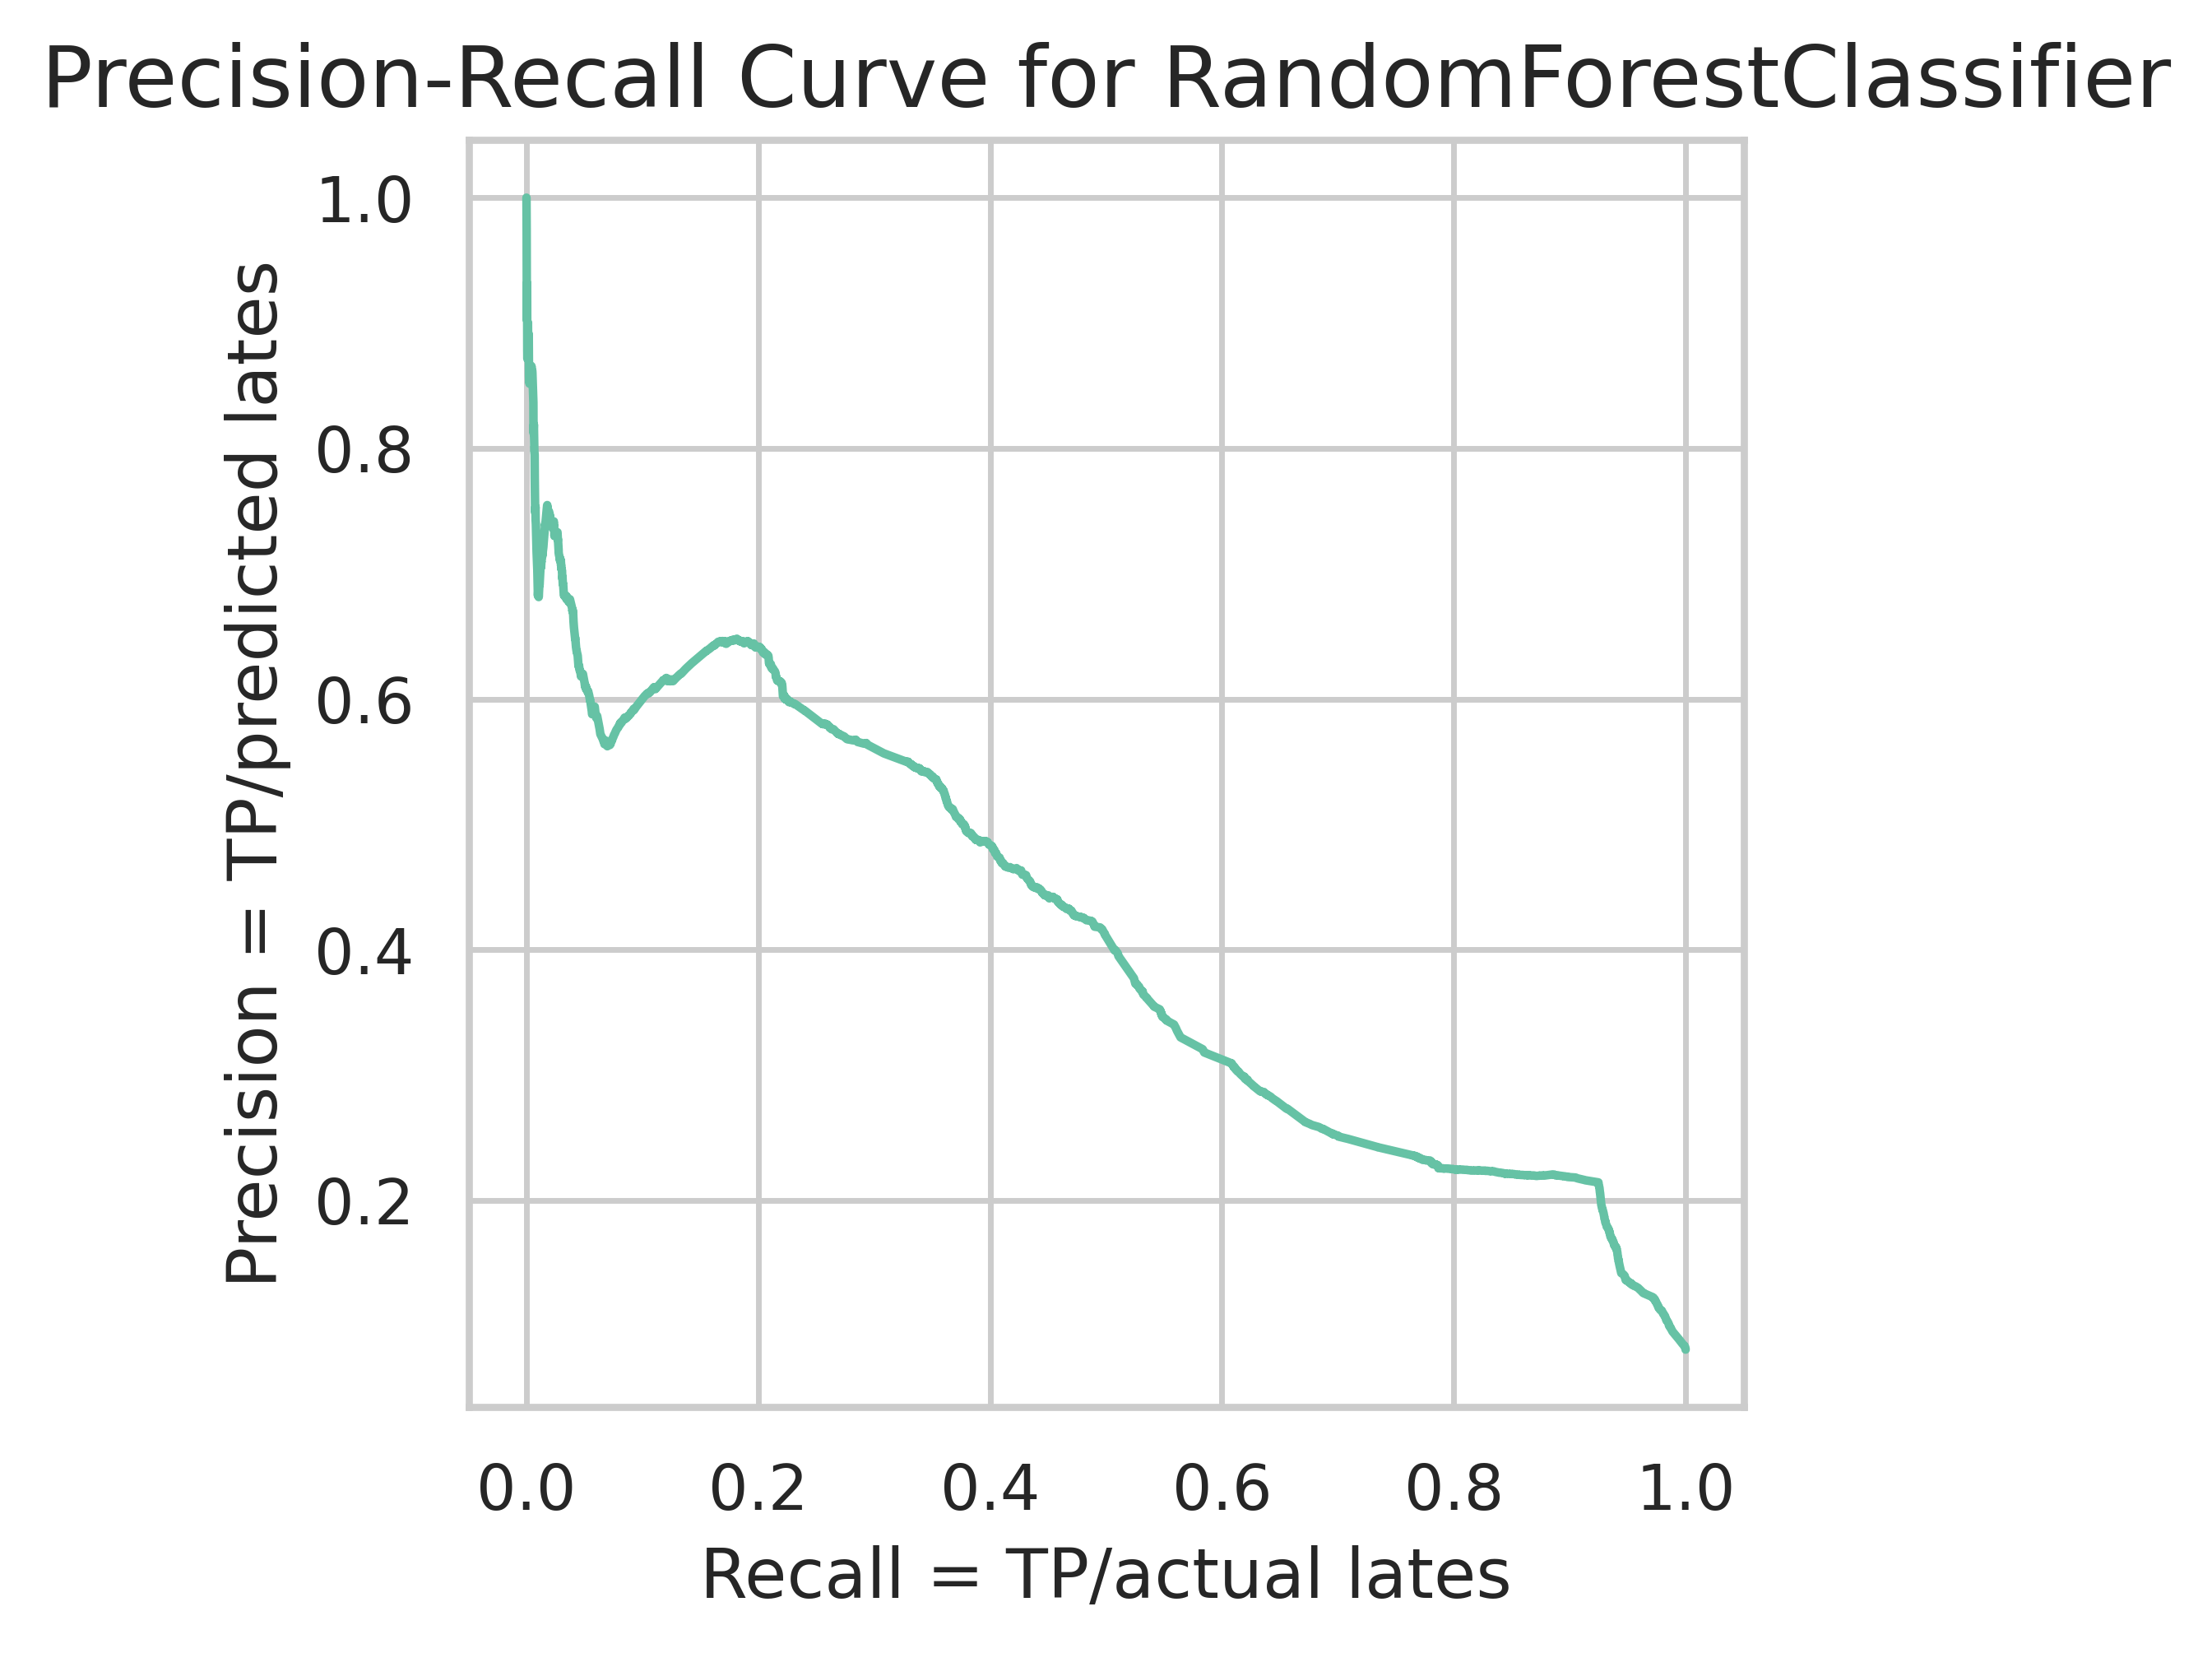

In [33]:
# Get predicted probabilities for the positive class
y_scores = rf_model.predict_proba(X)[:, 1]

# Compute precision-recall pairs
precision_train, recall_train, _ = precision_recall_curve(y, y_scores)

# Average precision
ap_train = average_precision_score(y, y_scores)

# Plot
plt.figure(figsize=(4, 4))
plt.plot(recall_train, precision_train, label=f"Train (AP={ap_train:.2f})")
plt.xlabel("Recall = TP/actual lates")
plt.ylabel("Precision = TP/predicted lates")
plt.title(f"Precision-Recall Curve for {rf_model_name}")
plt.grid(True)
plt.show()

In [34]:
# Get feature importances
importances = rf_model.feature_importances_
# Build Dataframe
feat_imp_df = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

feat_imp_df.head(20)

,feature,importance
7,header_from_self_build,0.235087
5,block_gas_used,0.163939
9,header_from_ultrasound,0.121457
3,block_total_bytes_compressed,0.106699
1,p66_block_arrival_ms,0.079027
6,block_tx_count,0.075272
17,entity_figment,0.069240
8,header_from_titan,0.045943
0,p95_block_arrival_ms,0.036234
11,entity_binance,0.027419


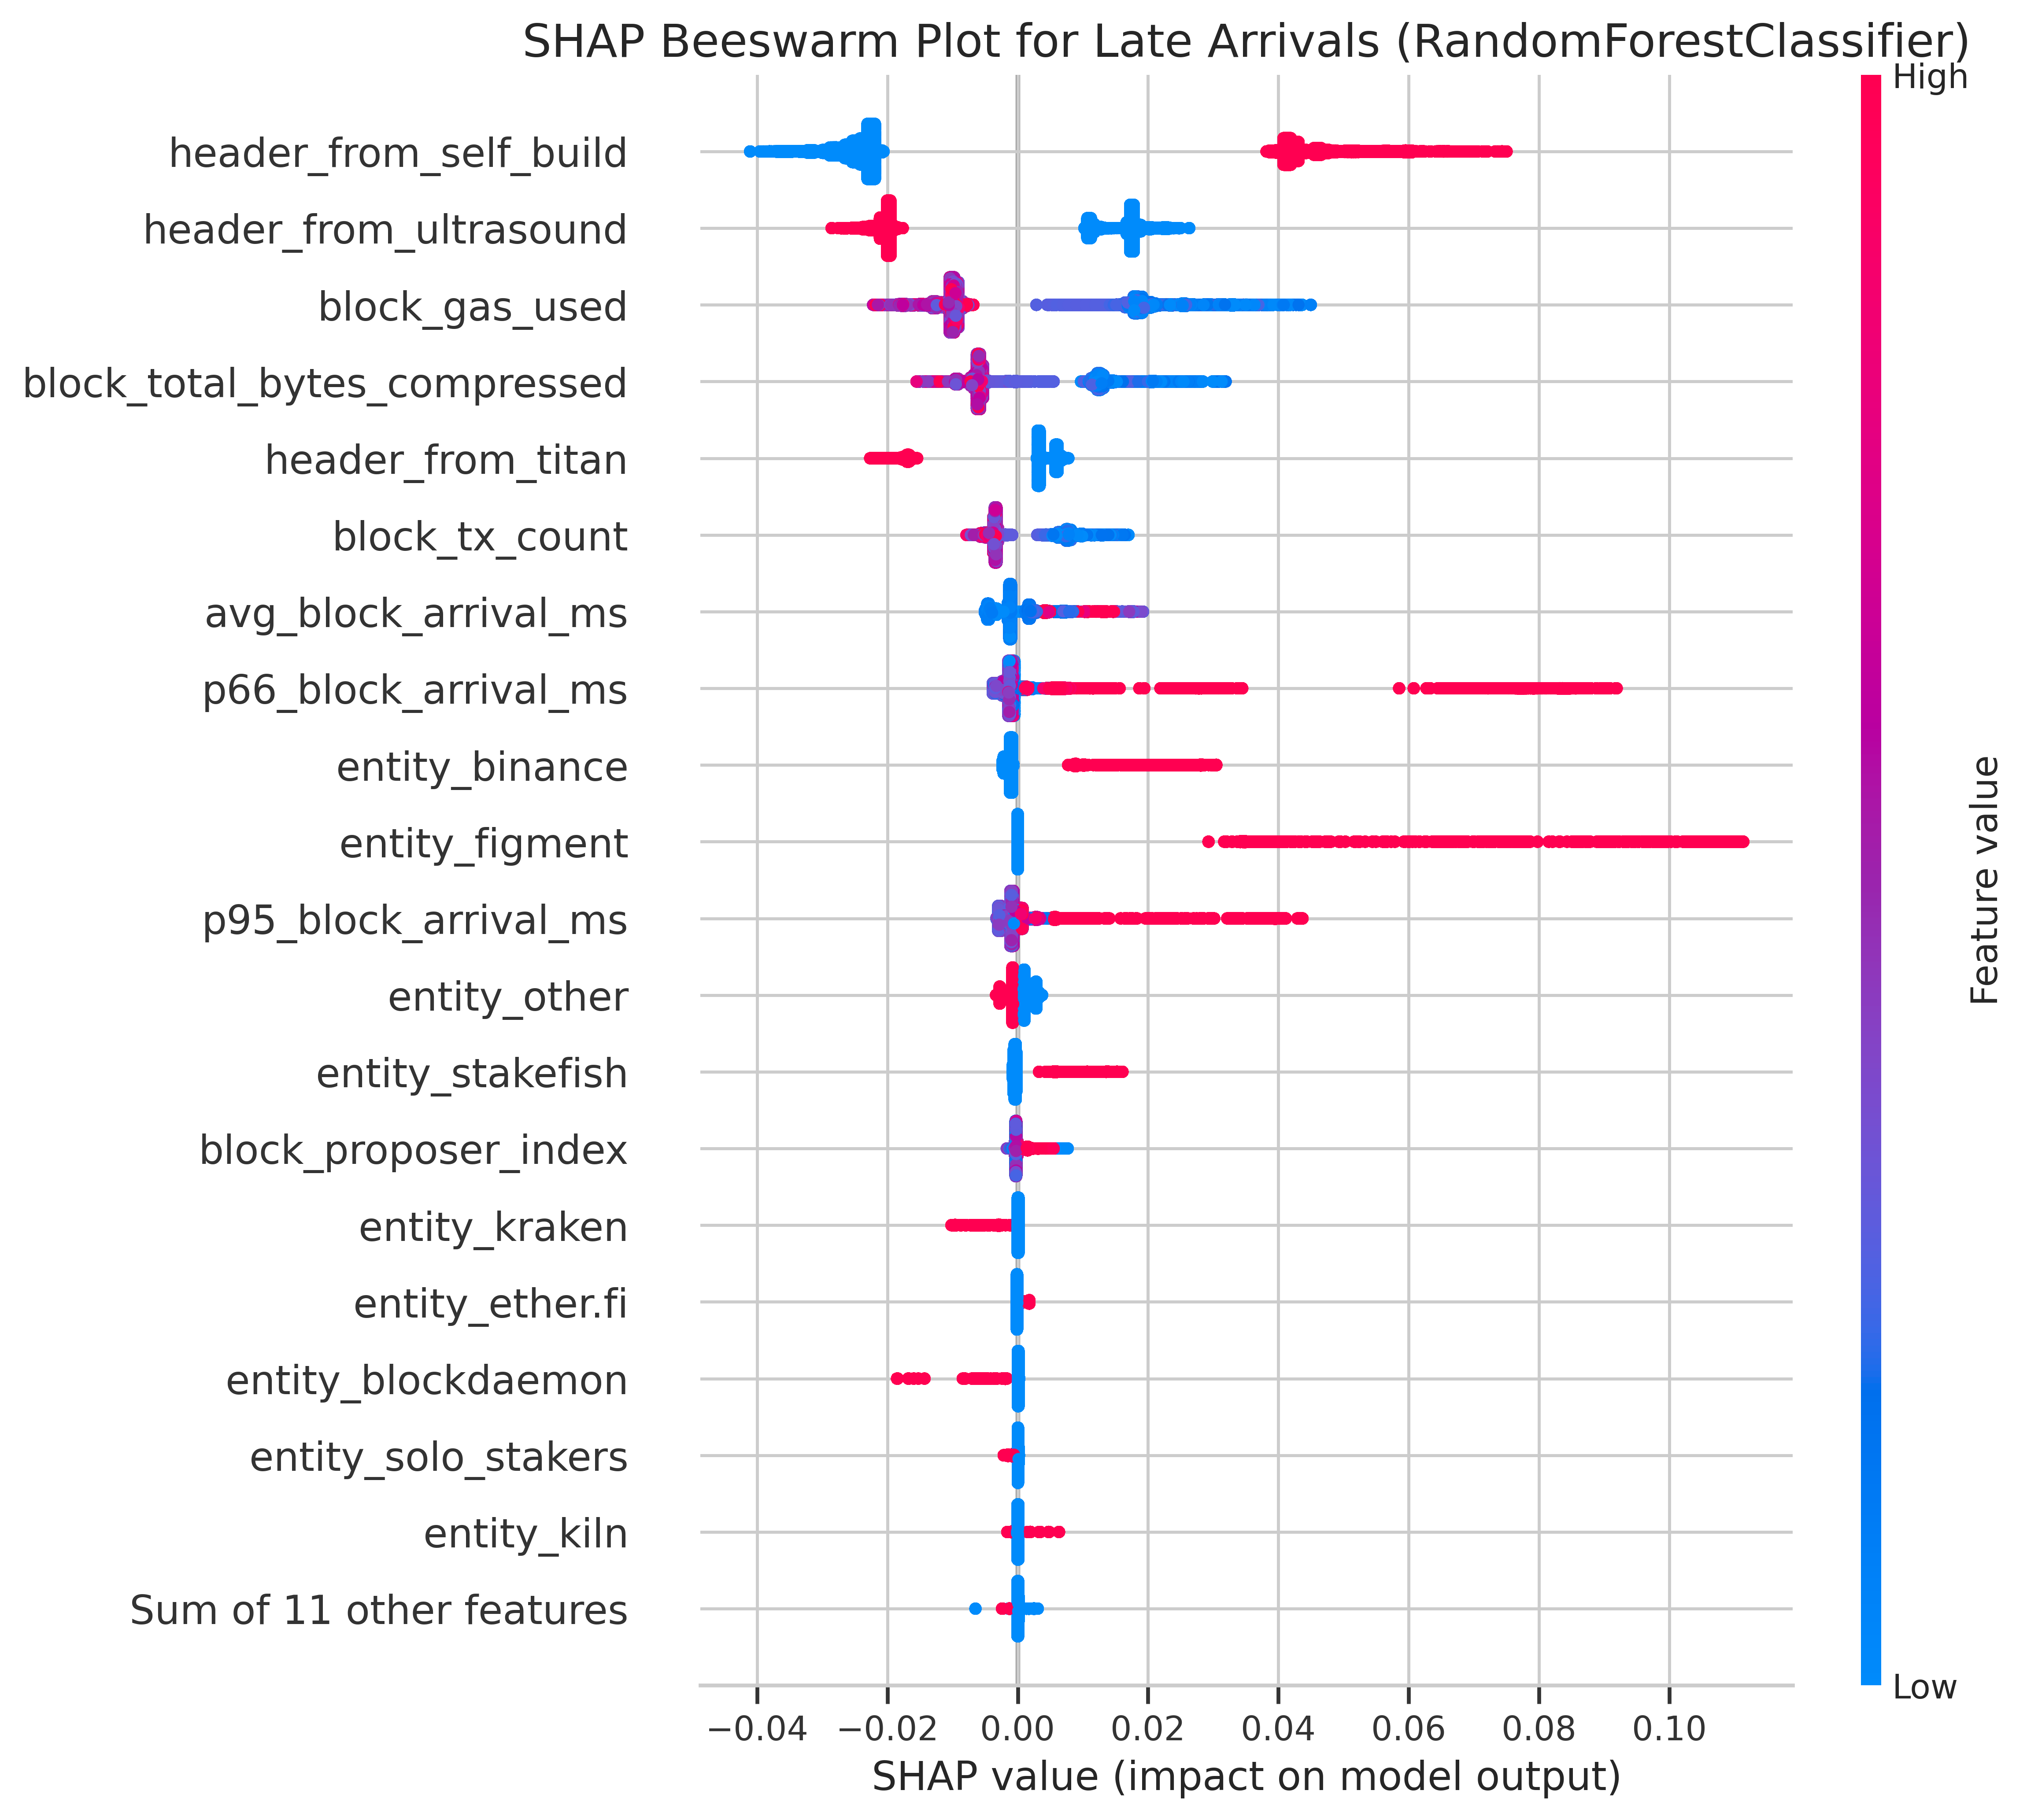

In [35]:
# Load shap values 
shap_path = os.path.join(
    model_out_dir, rf_model_name, "shap.pkl"
)
with open(shap_path, "rb") as f:
    explanation = pickle.load(f)
# Plot summary for the positive class (late arrivals)
shap.plots.beeswarm(explanation[:,:,1], max_display=20, show=False)
plt.title(f"SHAP Beeswarm Plot for Late Arrivals ({rf_model_name})")
plt.show()

### LightGBM Classifier

In [8]:
# Load model
lgbm_model_name = "LGBMClassifier"
model_path = os.path.join(
    model_out_dir, lgbm_model_name, "model.pkl"
)
with open(model_path, "rb") as f:
    lgbm_model = pickle.load(f)

# Evaluate the model
print(
    classification_report(
        y, lgbm_model.predict(X), target_names=["on-time", "late"], digits=3
    )
)

              precision    recall  f1-score   support

     on-time      0.935     0.993     0.963   2626348
        late      0.720     0.211     0.326    231311

    accuracy                          0.929   2857659
   macro avg      0.827     0.602     0.644   2857659
weighted avg      0.917     0.929     0.911   2857659



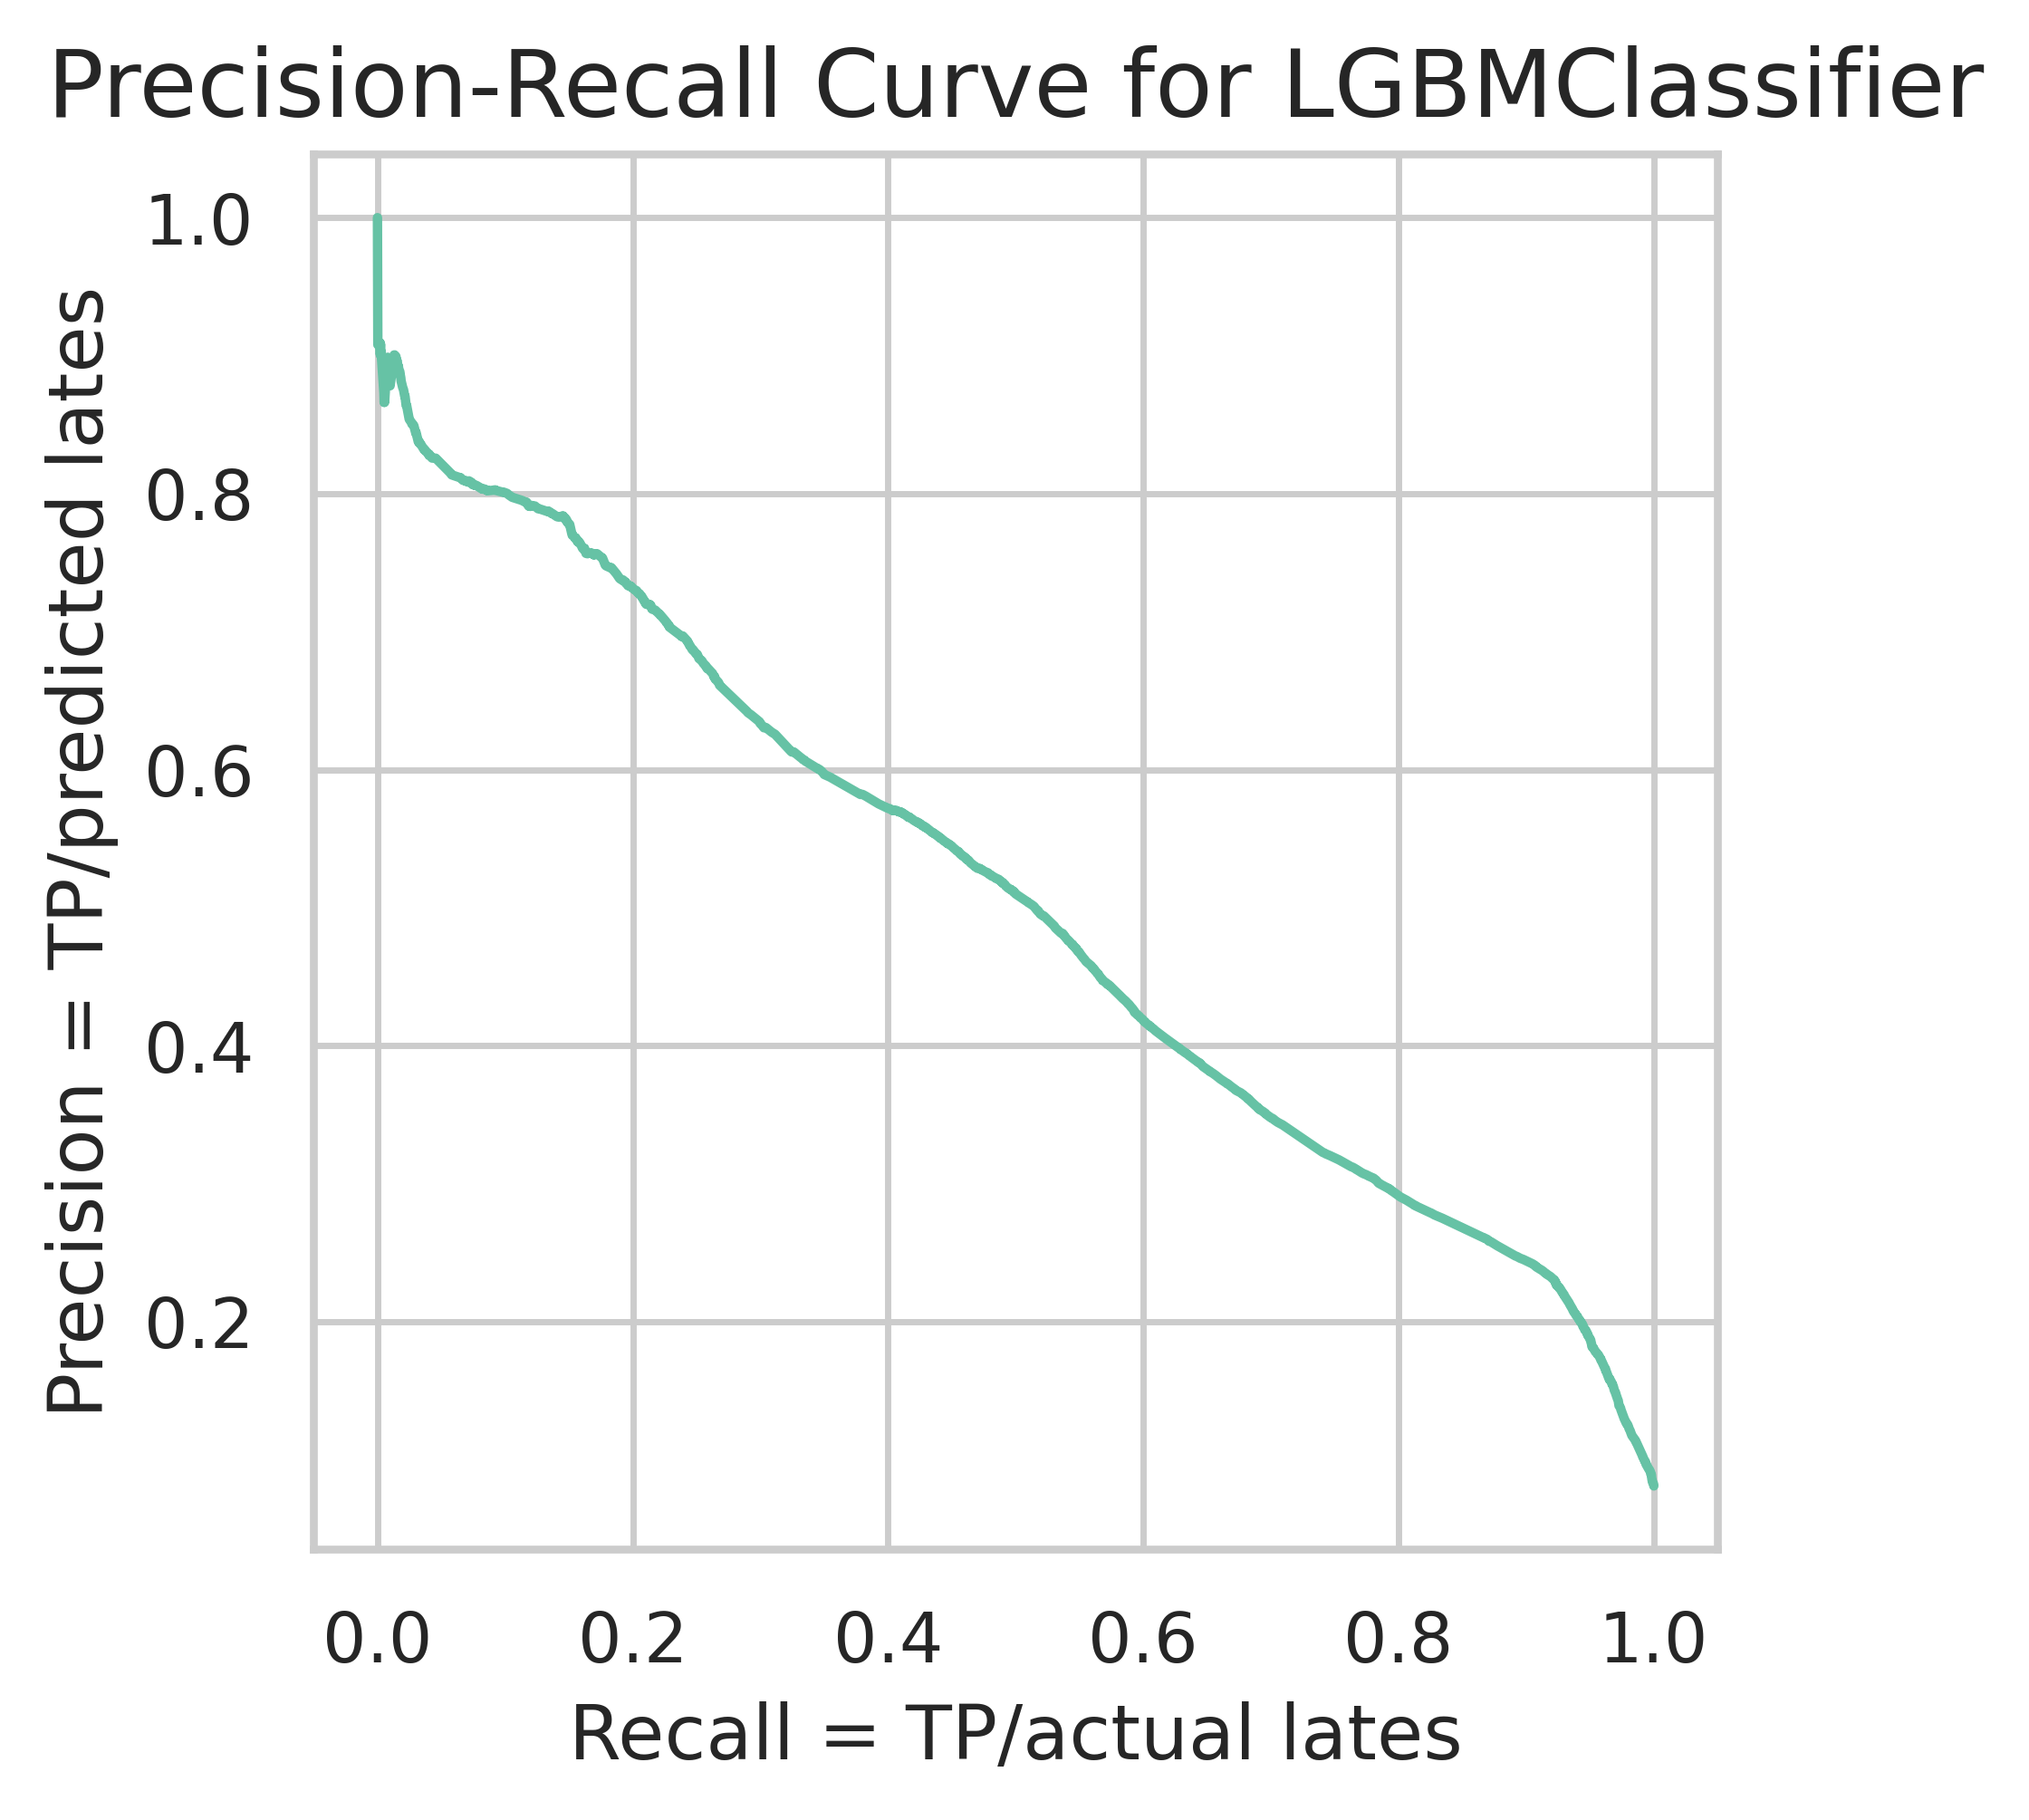

In [37]:
# Get predicted probabilities for the positive class
y_scores = lgbm_model.predict_proba(X)[:, 1]

# Compute precision-recall pairs
precision_train, recall_train, _ = precision_recall_curve(y, y_scores)

# Average precision
ap_train = average_precision_score(y, y_scores)

# Plot
plt.figure(figsize=(4, 4))
plt.plot(recall_train, precision_train, label=f"Train (AP={ap_train:.2f})")
plt.xlabel("Recall = TP/actual lates")
plt.ylabel("Precision = TP/predicted lates")
plt.title(f"Precision-Recall Curve for {lgbm_model_name}")
plt.grid(True)
plt.show()

In [38]:
# Get feature importances
importances = lgbm_model.feature_importances_
# Build Dataframe
feat_imp_df = pd.DataFrame(
    {"feature": feature_names, "importance": importances}
).sort_values("importance", ascending=False)

feat_imp_df.head(20)

,feature,importance
1,p66_block_arrival_ms,151
0,p95_block_arrival_ms,85
7,header_from_self_build,58
17,entity_figment,39
11,entity_binance,33
15,entity_ether.fi,31
5,block_gas_used,25
19,entity_kraken,25
13,entity_blockdaemon,22
2,avg_block_arrival_ms,22


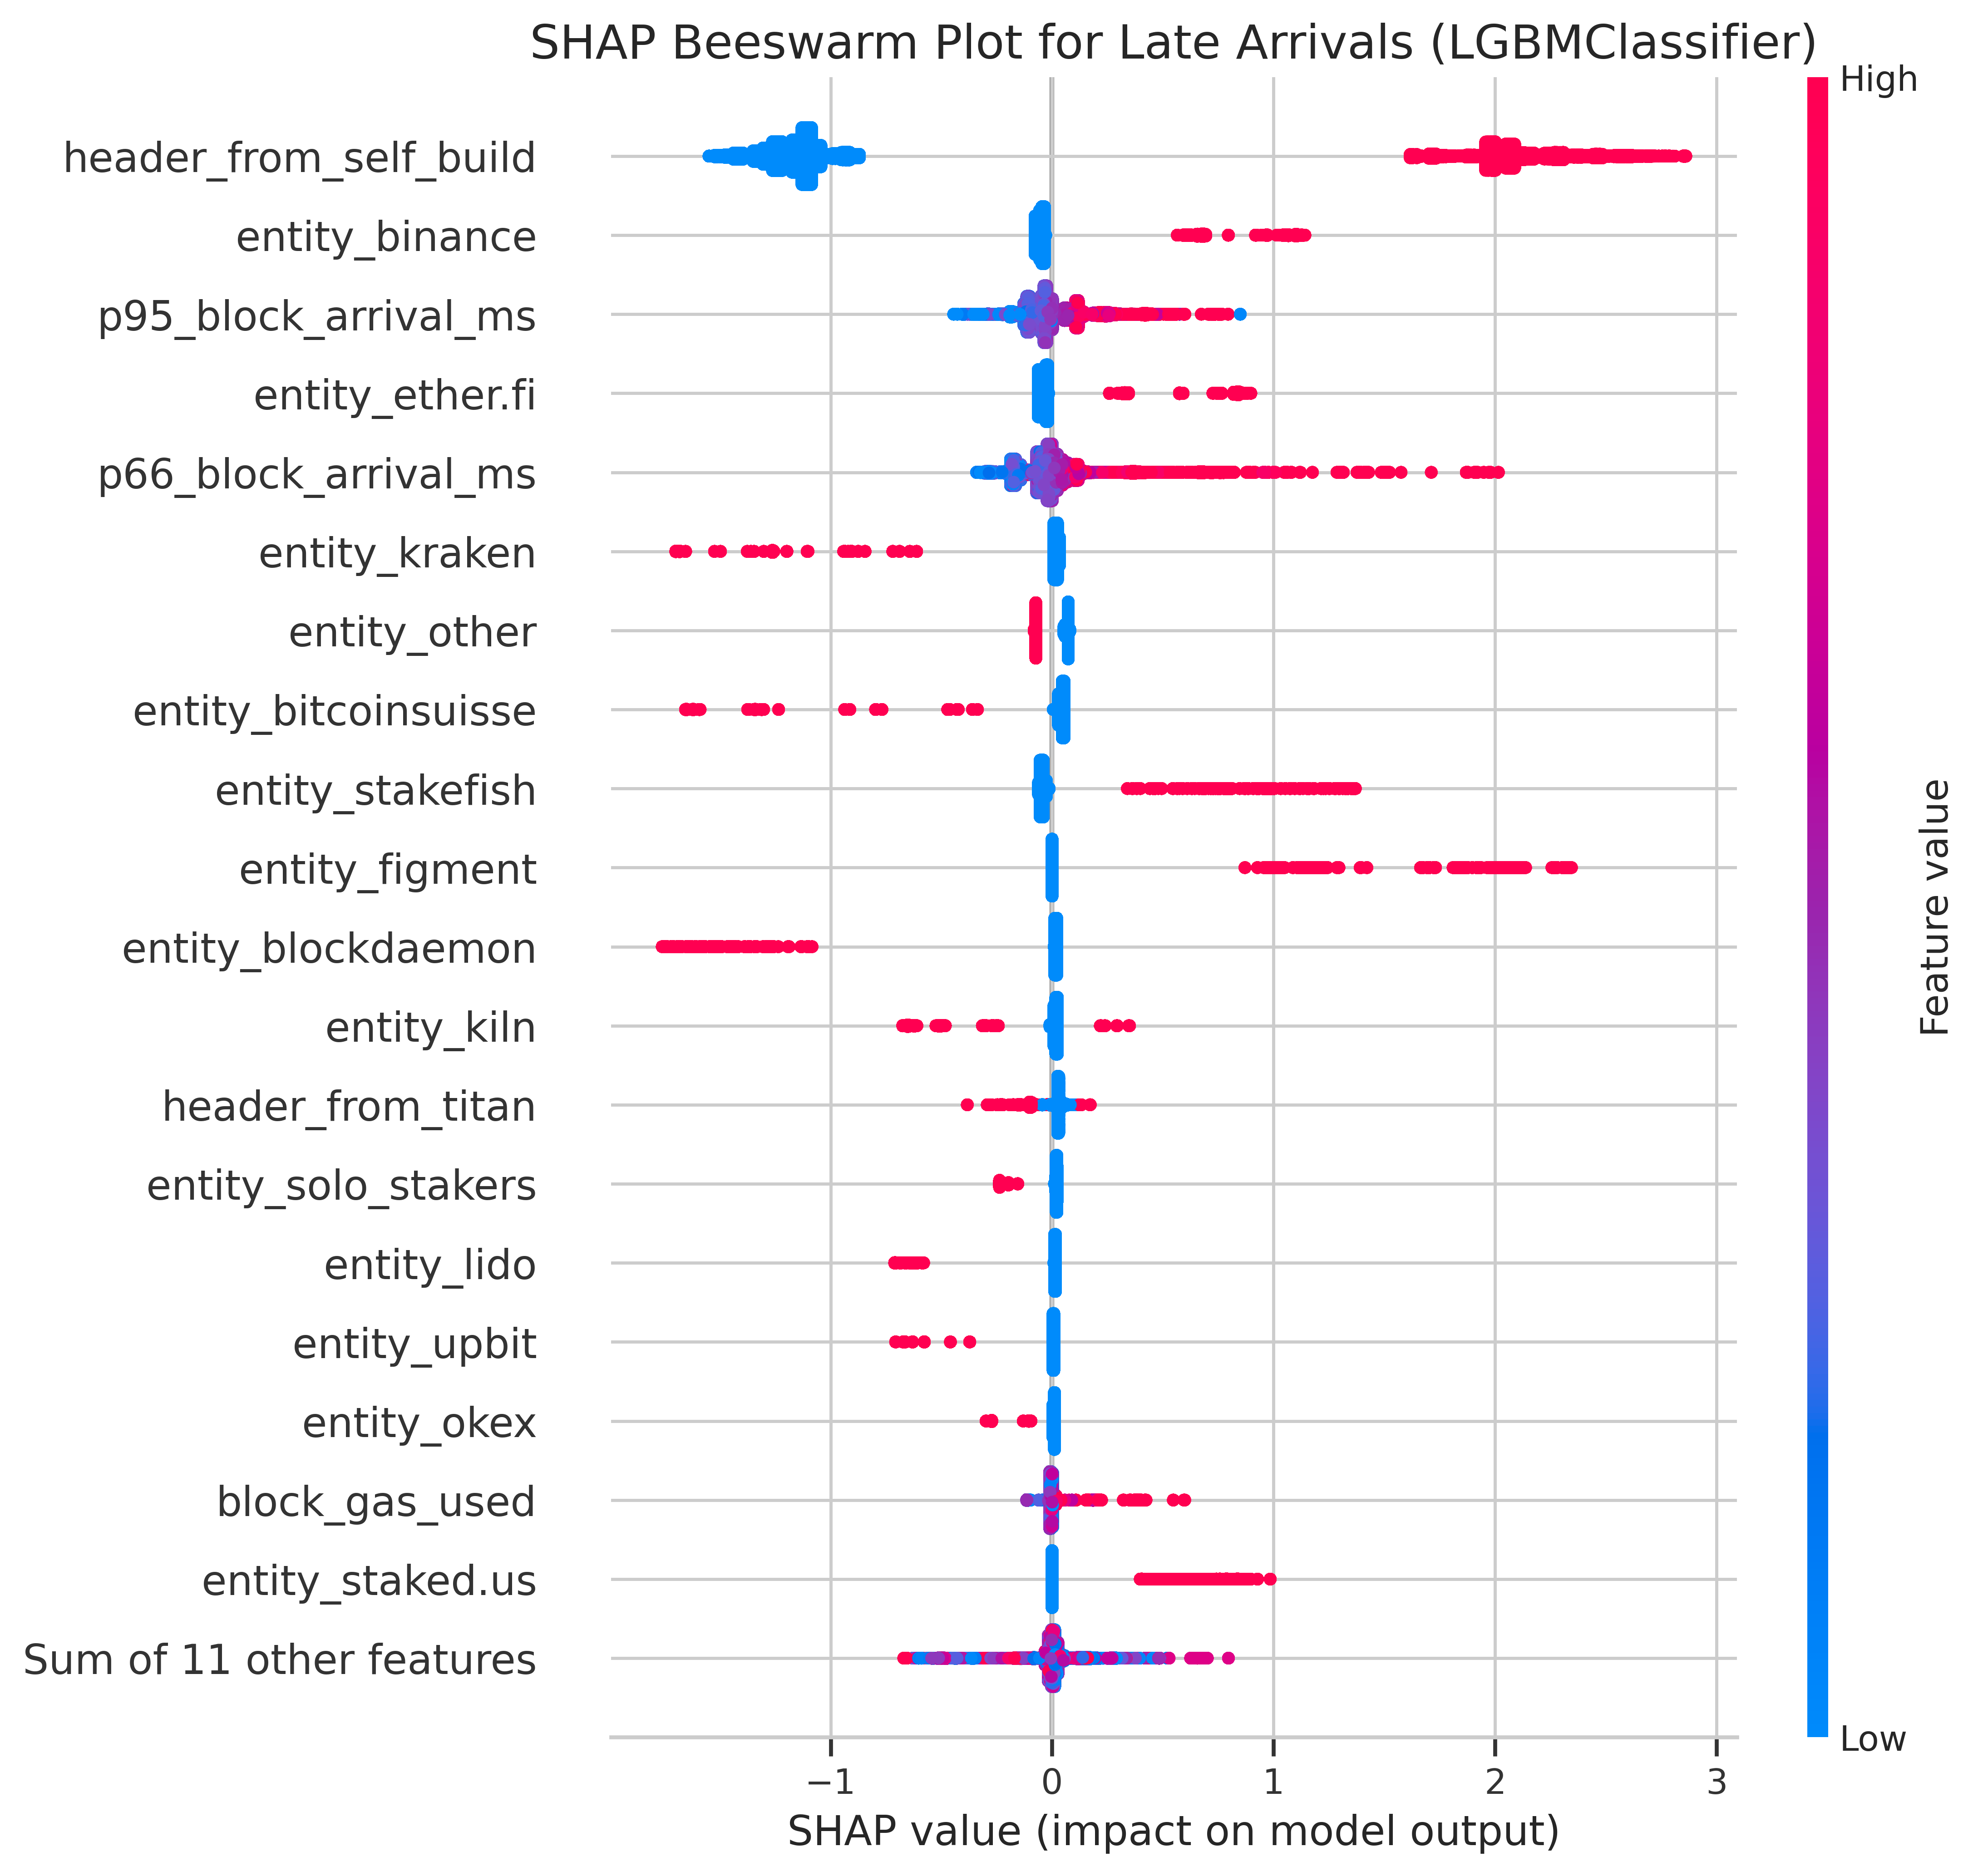

In [9]:
# Load shap values 
shap_path = os.path.join(
    model_out_dir, lgbm_model_name, "shap.pkl"
)
with open(shap_path, "rb") as f:
    explanation = pickle.load(f)
# Plot summary for the positive class (late arrivals)
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title(f"SHAP Beeswarm Plot for Late Arrivals ({lgbm_model_name})")
plt.show()

### Logistic regression

In [10]:
# Load model
reg_model_name = "LogisticRegression"
model_path = os.path.join(
    model_out_dir, reg_model_name, "model.pkl"
)
with open(model_path, "rb") as f:
    reg_model = pickle.load(f)

# Evaluate the model
print(
    classification_report(
        y, reg_model.predict(X), target_names=["on-time", "late"], digits=3
    )
)

              precision    recall  f1-score   support

     on-time      0.935     0.991     0.962   2626348
        late      0.668     0.212     0.322    231311

    accuracy                          0.928   2857659
   macro avg      0.801     0.601     0.642   2857659
weighted avg      0.913     0.928     0.910   2857659



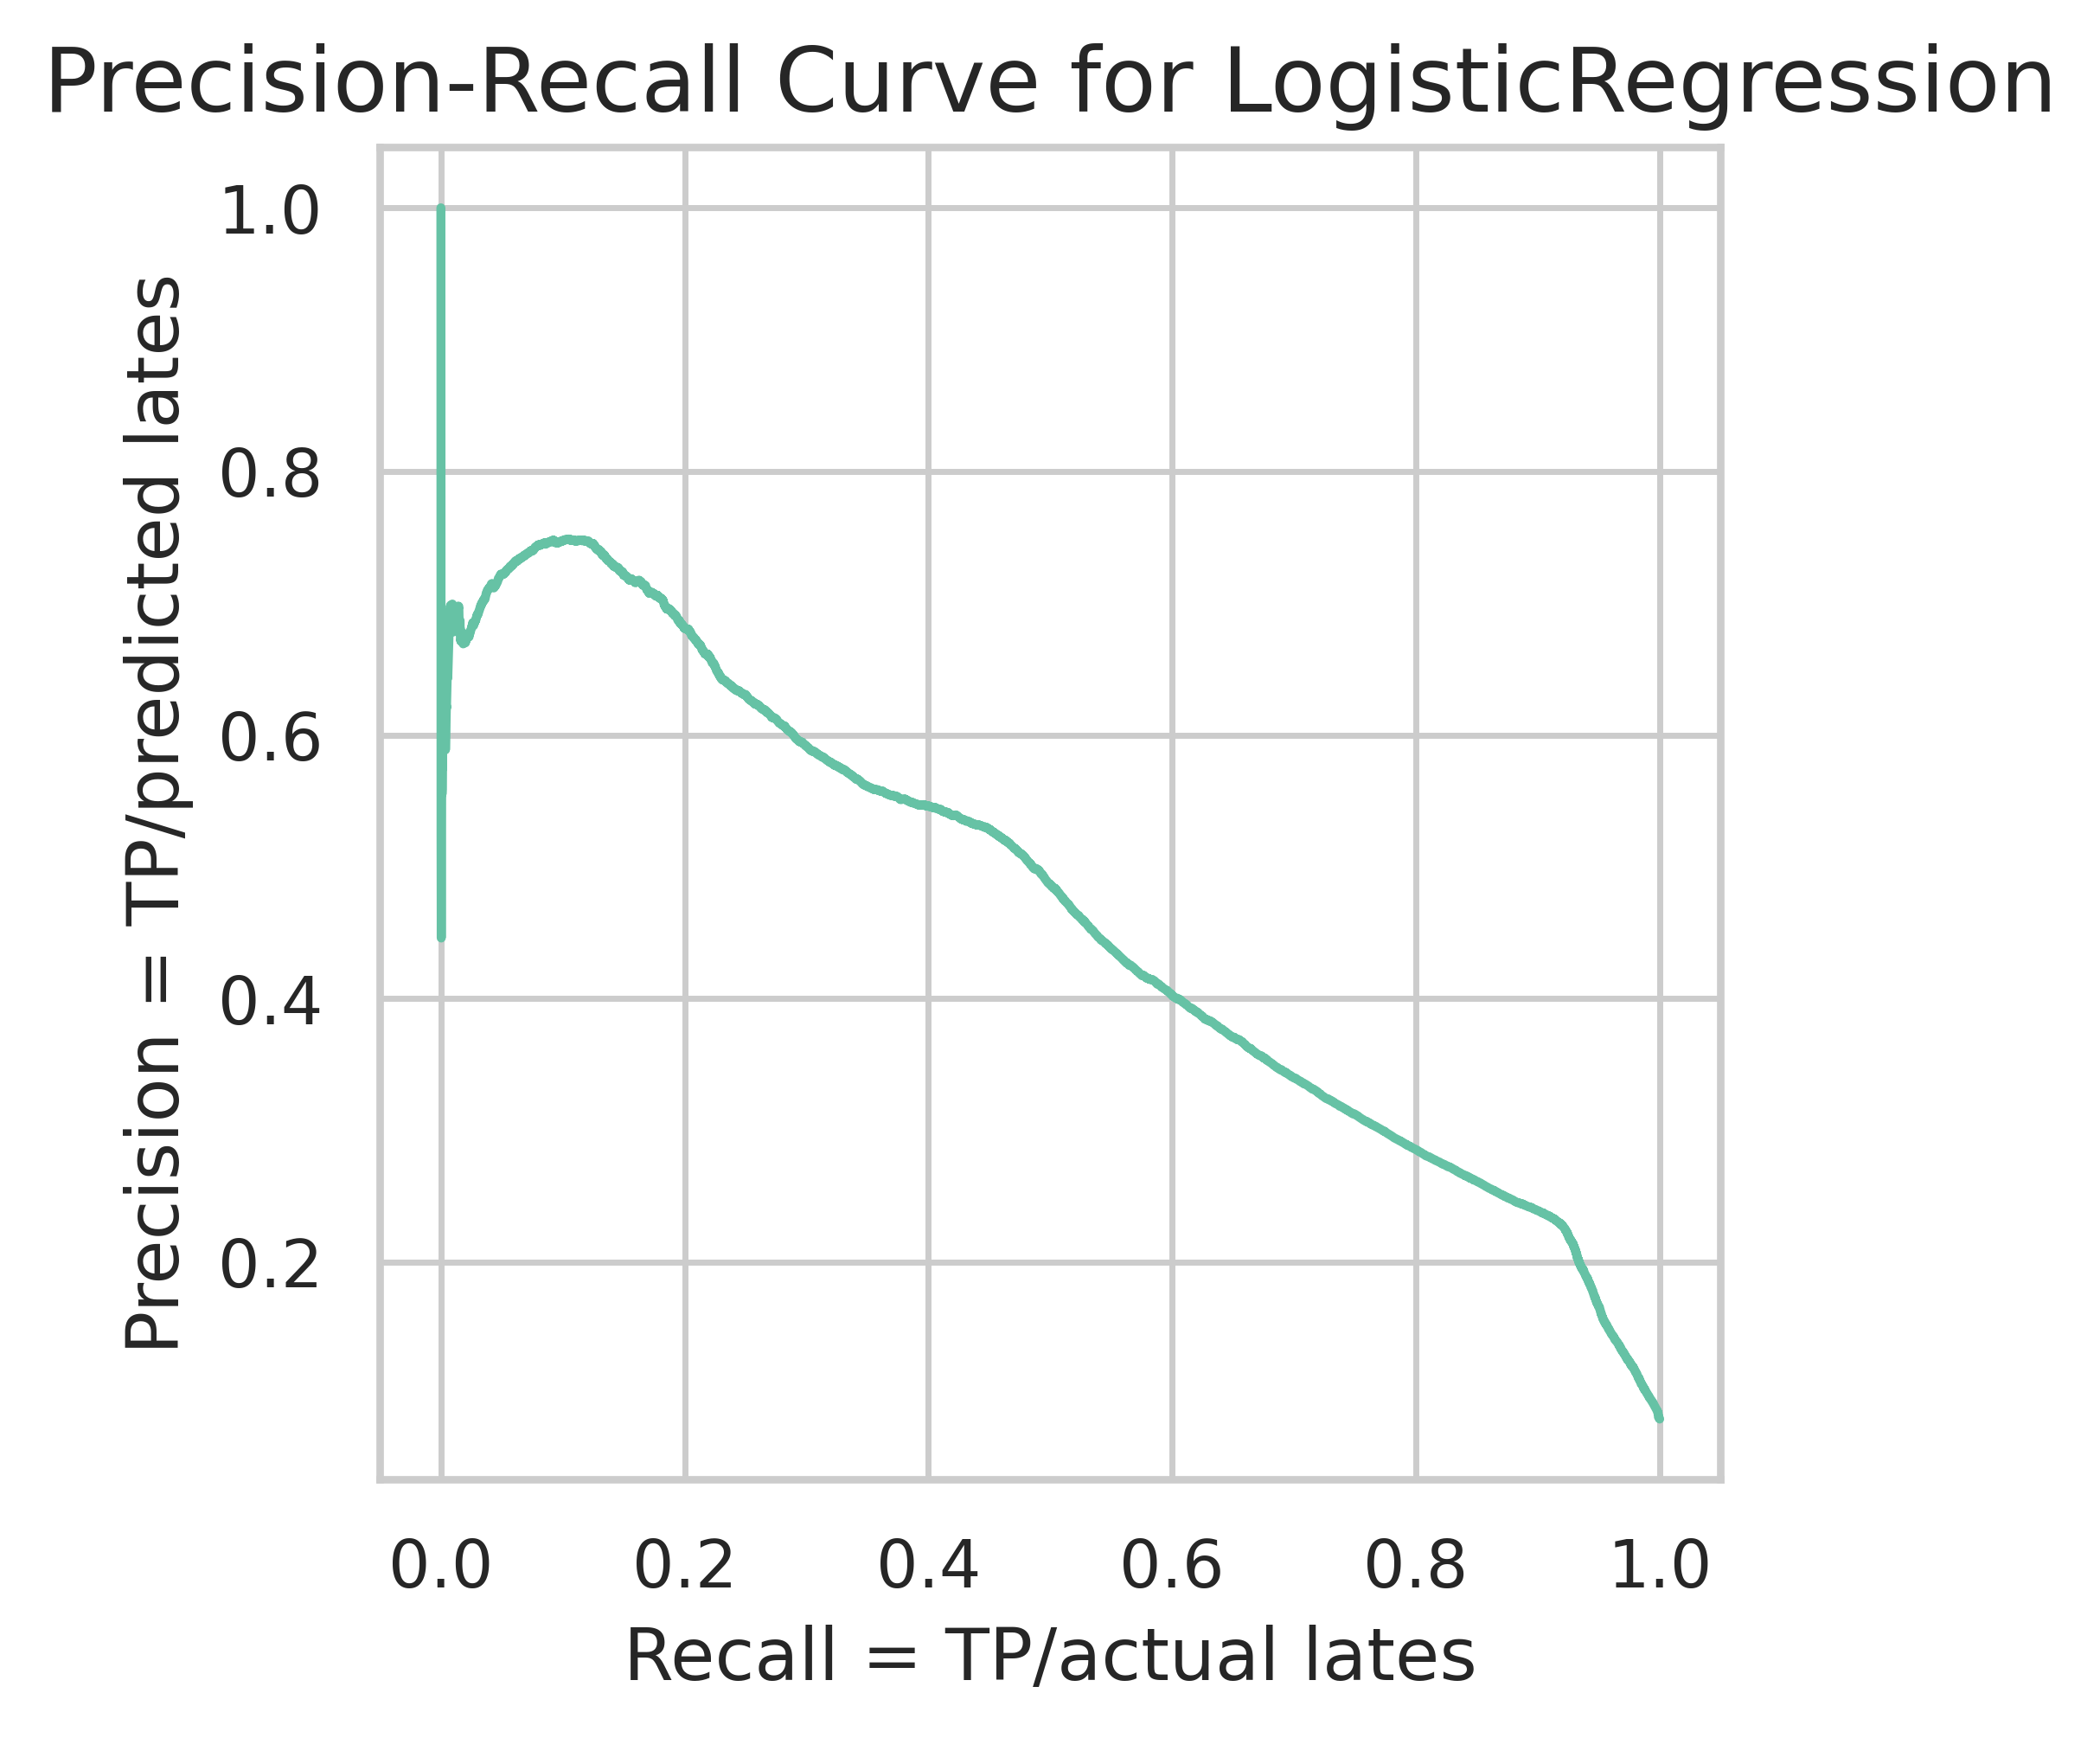

In [11]:
# Get predicted probabilities for the positive class
y_scores = reg_model.predict_proba(X)[:, 1]

# Compute precision-recall pairs
precision_train, recall_train, _ = precision_recall_curve(y, y_scores)

# Average precision
ap_train = average_precision_score(y, y_scores)

# Plot
plt.figure(figsize=(4, 4))
plt.plot(recall_train, precision_train, label=f"Train (AP={ap_train:.2f})")
plt.xlabel("Recall = TP/actual lates")
plt.ylabel("Precision = TP/predicted lates")
plt.title(f"Precision-Recall Curve for {reg_model_name}")
plt.grid(True)
plt.show()

In [12]:
# Get coeficients
coefs = reg_model.coef_.reshape(-1)
# Build Dataframe
coef_df = pd.DataFrame(
    {"feature": feature_names, "coefs": coefs}
).sort_values("coefs", ascending=False)

coef_df.head(20)

,feature,coefs
17,entity_figment,2.381736
7,header_from_self_build,1.583808
28,entity_stakefish,1.485302
11,entity_binance,1.376261
27,entity_staked.us,1.075774
16,entity_everstake,0.495966
1,p66_block_arrival_ms,0.342208
15,entity_ether.fi,0.287901
14,entity_coinbase,0.264391
25,entity_rocketpool,0.172306


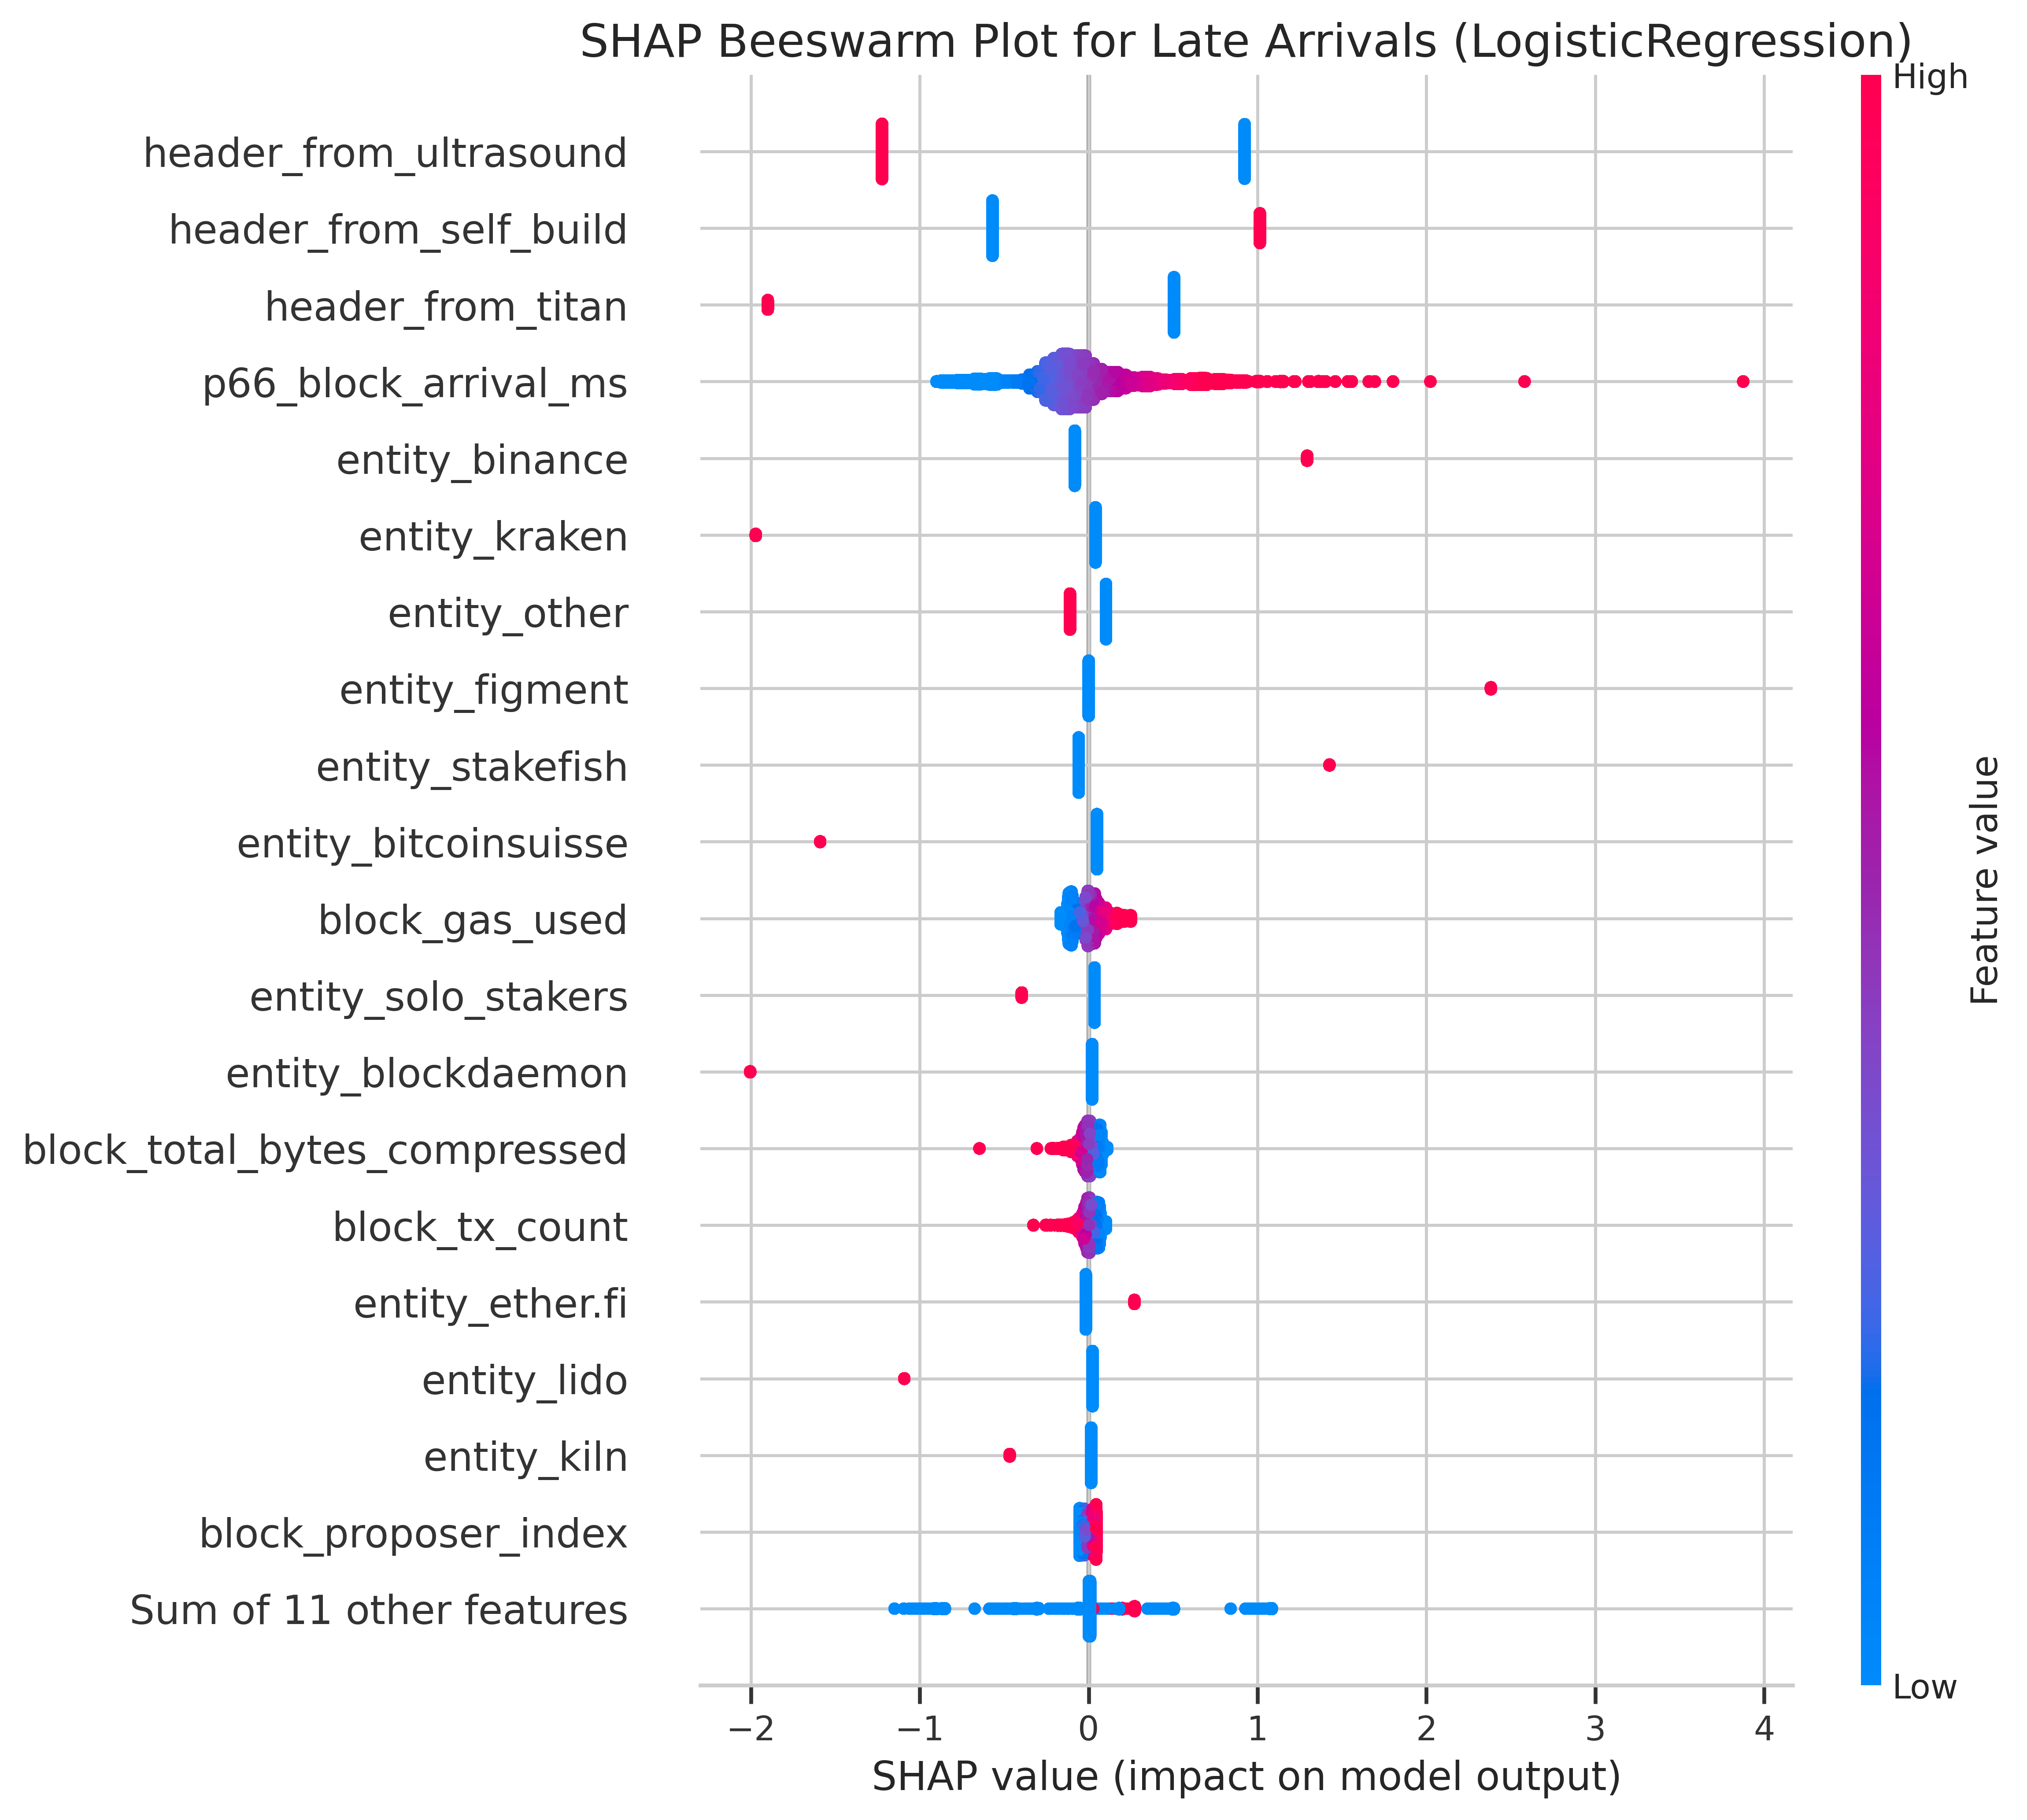

In [13]:
# Load shap values 
shap_path = os.path.join(
    model_out_dir, reg_model_name, "shap.pkl"
)
with open(shap_path, "rb") as f:
    explanation = pickle.load(f)
# Plot summary for the positive class (late arrivals)
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title(f"SHAP Beeswarm Plot for Late Arrivals ({reg_model_name})")
plt.show()